# 06. 세션 간 구매 여정 분석

## 분석 개요

- 목적: 04의 같은 세션 strict 3단계 퍼널과 05의 예비 진단을 이어, 동일 사용자·상품 행동이 세션 경계를 넘어 purchase로 연결되는 경로를 확인한다.
- 방침 원천: `docs/metrics.md`(단일 원천). 이 노트북은 방침을 변경하지 않는다.
- 데이터 소스: 02에서 raw 대조 검증을 통과한 `mart_user_product_session`과 기존 검증 마트만 소비한다. raw(`events`)는 조회하지 않는다.
- 분석 단위: §1·§4는 사용자·상품, §2는 purchase가 있는 세션·상품, §3·§3-1은 구매 에피소드의 시간 분포, §5·§5-1은 remove-only 세션·상품이다.
- 경로 기준: strict 시각 순서를 사용하고, 이전 동일 상품 purchase에서 에피소드를 끊는다. 구매 차수와 구매 경로는 별도 축으로 분류한다.
- 해석 원칙: 관측 첫 구매·반복 구매는 관측 기간 안의 구분이며, 경로 연결은 로그에서 확인된 선행 행동이지 인과 또는 장바구니 상태의 확정 증거가 아니다.

## 06 분석 브리프

프로젝트 전체의 가상 실무 요청과 문제 정의는 [`README.md`](../README.md)에 정리했다. 06은 그중 **세션 단위 퍼널 밖 구매를 실제 시각으로 연결하고, CRM 개입 후보와 시점을 한 가지로 좁히는 문제**를 담당한다.

### 분석 흐름

| 단계 | 한 줄 주제 | 이 단계에서 답할 질문 |
|---|---|---|
| §1 | **얼마나 놓치는가?** | 동일 세션 `view → cart → purchase`만 전환으로 인정하면 동일 상품 구매를 얼마나 포착하지 못하는가? |
| §2 | **왜 놓치는가?** | 실제 구매는 현재 세션의 3단계 완주, 다른 세션 cart 연결, cart 미확인 등 어떤 경로로 나뉘는가? |
| §3 | **가장 큰 경로를 더 보면 무엇이 보이는가?** | §2에서 가장 크게 관찰된 `다른 세션 cart → 현재 purchase`에는 실제로 얼마나 시간이 걸리는가? |
| §3-1 | **첫 24시간 안에서는 언제 집중되는가?** | 24시간 미만 구매를 다시 나누면 어느 시간대에 집중되고 구매 차수별 분포는 어떻게 다른가? |
| §4 | **기존의 낮은 전환 신호는 여전히 남는가?** | 04 우선진단 카테고리의 낮은 구매 도달은 세션을 통합한 30일 동일 상품 구매를 포함하면 해소되는가? |
| §5 | **남은 상태 예외는 무엇을 말하는가?** | cart·purchase 없이 remove만 있는 세션·상품의 직전 동일 상품 상태 이벤트는 무엇인가? |
| §5-1 | **미확인의 이유를 좁힐 수 있는가?** | 이전 상태 미확인 비율은 관측 시작에 가까운 2019-10에 더 높은가? |
| §6.1 | **실험으로 옮길 수 있는가?** | cart+24시간 CRM 실험의 자연 구매 기준선과 필요한 표본은 얼마인가? |

이 흐름은 앞 단계의 발견이 다음 질문을 만드는 **분석 논리의 연결**이다. §1·§4는 사용자·상품, §2는 구매가 있는 세션·상품, §3·§3-1은 구매 에피소드와 시간 분포, §6.1은 사용자별 최초 cart에서 만든 실험 적격 cohort를 단위로 한다. §5는 구매 전환 본선이 아니라 04에서 남은 remove-only 상태 예외를 닫는 보조 진단이다. 따라서 각 섹션을 동일 모집단이 차례로 줄어드는 하나의 수치 퍼널로 해석하지 않는다.

### 검토 가설·분석 질문과 확인 기준

| 구분 | 검토 내용 | 관찰 데이터 확인 기준 | 연결 섹션 |
|---|---|---|---|
| 가설 1 | 동일 사용자·상품 분모에서도 세션 통합 N일 동일 상품 구매 도달률은 같은 세션 3단계 완주율보다 높게 나타날 것이다. | 최초 view 후 N일 구매 판정 가능 조합을 공통 분모로 두고 두 지표의 분자와 비율을 비교한다. | §1 |
| 가설 2 | 이전 동일 상품 구매보다 앞선 행동을 제외한 뒤에도 `다른 세션 cart → 현재 purchase`가 가장 큰 구매 경로일 것이다. | 구매 세션·상품을 여섯 경로로 배타적으로 나눠 전체 규모를 비교한다. | §2 |
| 분석 질문 2-1 | 관측 첫 구매와 반복 구매의 구매 전 cart 미확인 비중은 얼마나 다르며, 차이는 어느 세부 경로에 집중되는가? | 구매 차수별 cart 미확인 비중과 세부 경로 구성을 기술한다. 방향은 판정하지 않는다. | §2 |
| 가설 3 | §2에서 확인한 다른 세션 cart 연결 구매의 실제 cart→purchase 시각 차이는 24시간 미만에 과반이 분포할 것이다. | 24시간 미만 구매 에피소드 비중이 50%를 넘는지 확인한다. | §3 |
| 분석 질문 3-1 | 다른 세션 cart 연결 구매의 시간 분포는 관측 첫 구매와 반복 구매에서 얼마나 다른가? | 구매 차수별 24시간 미만·7일 미만 누적 비중을 비교한다. | §3 |
| 가설 4 | 04 우선진단 카테고리는 세션 밖 구매를 포함한 30일 구매 도달에서도 그 외 카테고리보다 낮을 것이다. | 두 집단의 사용자·상품 30일 구매 도달률을 비교한다. | §4 |
| 분석 질문 5 | cart·purchase 없이 remove만 있는 세션·상품의 직전 동일 상품 상태 이벤트는 무엇인가? | 과거 cart 이력 존재율과 remove 직전의 가장 최근 cart·purchase·remove를 분리해 기술한다. | §5 |
| 후속 검토 가설 5-1 | 이전 상태 미확인은 관측 시작에 가까운 remove-only 조합에서 더 높게 나타날 것이다. | 2019-10과 2019-11-2020-02 통합 미확인 비율을 비교하고 개별 월 추이를 보조로 제시한다. | §5-1 |

§5는 04의 remove-only 예외를 정리하는 보조 분석이다. 50% 같은 임의 기준을 판정하지 않고 직전 상태별 규모를 확인한 뒤, 그 결과에서 파생된 §5-1에서 좌측 절단 가능성을 월별로 점검한다. 위 결과는 관찰 로그에서 예상 방향과 일치하는지 확인하는 것이며 인과효과 검증이 아니다. 최종 액션의 효과는 별도 무작위 A/B 테스트로 검증해야 한다.

In [1]:
import math
import os
import re
import time
from pathlib import Path
from statistics import NormalDist
from urllib.parse import quote_plus

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

load_dotenv()
engine = create_engine(
    f"mysql+pymysql://{os.getenv('DB_USER')}:{quote_plus(os.getenv('DB_PASSWORD'))}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}?charset=utf8mb4"
)

color_map = {
    'view': '#3B82F6',
    'cart': '#F59E0B',
    'purchase': '#10B981',
    'remove': '#EF4444',
}

In [2]:
def find_sql(name):
    for base in (Path.cwd(), Path.cwd().parent):
        cand = base / 'sql' / name
        if cand.exists():
            return cand
    raise FileNotFoundError(f'sql/{name} 없음 (cwd={Path.cwd()})')

SQL_FILE = find_sql('06_purchase_journey_analysis.sql')
CACHE_DIR = SQL_FILE.parent.parent / 'cache'

def load_queries(path):
    body = Path(path).read_text(encoding='utf-8')
    parts = re.split(r'(?m)^--\s*name:\s*(\w+).*$', body)
    return {parts[i]: parts[i + 1].strip() for i in range(1, len(parts), 2)}

Q = load_queries(SQL_FILE)

def run(name, refresh=False, **kwargs):
    cache_path = CACHE_DIR / f'{name}.parquet'
    if cache_path.exists() and not refresh:
        try:
            df = pd.read_parquet(cache_path)
            print(f'[{name}] 캐시 로드 · {len(df):,}행')
            return df
        except Exception:
            pass
    t0 = time.time()
    df = pd.read_sql(text(Q[name]), engine, **kwargs)
    elapsed = time.time() - t0
    try:
        CACHE_DIR.mkdir(exist_ok=True)
        df.to_parquet(cache_path, index=False)
        note = '→ 캐시 저장'
    except Exception as e:
        note = f'(캐시 미저장: {type(e).__name__})'
    print(f'[{name}] 실행 {elapsed:.1f}s · {len(df):,}행 {note}')
    return df

---
## 1. 분석 단위를 바꾸면 구매 도달은 얼마나 달라지는가

**비즈니스 질문.** 동일 세션의 `view → cart → purchase`만 전환으로 정의하면 사용자·상품 관점의 구매 도달을 얼마나 놓치는가?

**검토 가설 1.** 사용자·상품의 구매 경로에는 세션 간 구매와 cart 미경유 구매가 포함된다. 따라서 동일한 사용자·상품 분모에서도 세션 통합 N일 동일 상품 구매 도달률은 같은 세션 3단계 완주율보다 높게 나타날 것이다.

**가설 수립 근거 — `04_funnel_eda.ipynb` §3·`05_purchase_journey_eda.ipynb` §3.** 04 §3에서 view와 purchase가 함께 있지만 cart가 없는 세션 9,725개가 확인돼 cart 미경유 구매 후보가 존재했다. 05 §3에서는 같은 세션에서 완전한 `view → cart → purchase`가 확인되지 않은 purchase 1,089,512개 중 556,137개(51.04%)에서 이전 세션의 동일 상품 cart가 확인됐다. 두 관찰을 바탕으로, 같은 세션 3단계 지표가 세션 간 구매와 cart 미경유 후보를 얼마나 담지 못하는지 사용자·상품 단위에서 다시 측정한다.

**확인 기준.** 최초 view 후 N일을 끝까지 관측할 수 있는 사용자·상품을 공통 분모로 두고, 04식을 적용한 같은 세션 3단계 완주율과 cart·세션 경로를 제한하지 않은 구매 도달률을 비교한다.

04의 2.299%는 세션 안의 3단계 완주를 설명하는 지표다. 다만 상품 동일성과 세션 경계를 넘는 행동을 반영하지 않으므로 사용자·상품 관점의 N일 구매 도달이라는 질문에는 답하지 못한다. 06에서는 이 질문을 별도 지표로 정의하고, 같은 사용자·상품 분모에서 동일 세션 3단계 완주와 세션 통합 구매를 비교한다.

### N일 구매 여부를 판정할 수 있는 조합

기간별 분모에는 `최초 view 시각 + N일 ≤ 전체 관측 종료 시각`을 만족하는 사용자·상품 조합만 포함한다. 이는 **최초 view 이후 N일 동안의 로그가 끝까지 남아 있어 구매 여부를 판정할 수 있다**는 뜻이다.

```text
[포함 예시]
최초 view  2월 28일 10시 ── 1일 뒤 ──▶ 2월 29일 10시 ──▶ 관측 종료 2월 29일 23:59
→ 1일 전체를 볼 수 있으므로 1일 구매 지표의 분모에 포함

[제외 예시]
최초 view  2월 29일 10시 ──▶ 관측 종료 2월 29일 23:59 ── 데이터 없음 ──▶ 1일 뒤 3월 1일 10시
→ 데이터가 먼저 끝나므로 구매하지 않았다고 판정하지 않고 1일 분모에서 제외
```

| 출력 컬럼 | 의미 |
|---|---|
| `view확인_사용자상품수` | 관측 기간에 해당 상품을 한 번 이상 본 사용자·상품 조합 |
| `N일구매판정가능_사용자상품수` | 최초 view 이후 N일을 끝까지 관측할 수 있는 조합으로, N일 구매율의 분모 |
| `N일_세션통합구매_사용자상품수` | 동일 사용자의 동일 상품 행동을 여러 세션에 걸쳐 모았을 때 N일 안에 구매가 확인된 조합으로, N일 구매율의 분자 |
| `구매확인기간` | 최초 view 이후 구매를 확인할 기간으로, 행마다 1일·7일·30일 중 하나 |
| `구매판정가능_사용자상품수` | 해당 기간을 끝까지 관측할 수 있어 구매 여부를 판정할 수 있는 사용자·상품 조합 |
| `동일세션_view_cart_purchase완주_사용자상품수` | 같은 분모 중 동일 세션·동일 상품에서 strict `view → cart → 첫 purchase`가 해당 기간 안에 확인된 조합 |
| `세션통합_동일상품구매_사용자상품수` | 동일 사용자의 동일 상품 행동을 세션 구분 없이 모았을 때, 최초 view 후 해당 기간 안에 구매가 확인된 조합 |
| `다중purchase_경계주의_사용자상품수` | 한 세션·상품의 여러 purchase가 사용자·상품 최초 view 앞뒤에 걸쳐 있어, 마트의 첫·마지막 purchase 시각만으로 최초 view 이후의 정확한 첫 구매 시각을 특정하기 어려운 조합 |

분모에서 제외된 조합은 ‘구매하지 않은 조합’이나 ‘행동이 없는 조합’이 아니다. 최초 view가 관측 종료에 너무 가까워 N일 구매 여부를 끝까지 판단할 수 없는 **우측 절단 조합**이다.

In [3]:
session_benchmark = run('pj_session_benchmark')  # 04 §1의 원래 세션 단위 3단계 완주율(참고 기준, 직접 비교값 아님)
display(session_benchmark.round(3))

[pj_session_benchmark] 캐시 로드 · 1행


,view도달_세션수,동일세션_view_cart_purchase수,동일세션_view_cart_purchase완주율_pct
0,4245334.0,97600.0,2.299


In [4]:
journey_scope = run('pj_journey_scope')  # 02 검증 마트의 전체·구매·다중구매 규모(세션·상품 단위 1행, §2 합계 검증에 재사용)
display(journey_scope)

[pj_journey_scope] 캐시 로드 · 1행


,전체_세션상품수,구매_세션상품수,purchase_이벤트수,다중purchase_세션상품수
0,13385787,1221747.0,1229578.0,7608.0


In [5]:
user_product_purchase_window = run('pj_user_product_window')  # N일 구매 판정 가능 수와 세션 통합 동일 상품 구매 수(§1 비교·§4 카테고리에 재사용)
for days in (1, 7, 30):
    purchase_judgement_count_column = f'{days}일구매판정가능_사용자상품수'
    purchase_confirmed_count_column = f'{days}일_세션통합구매_사용자상품수'
    purchase_rate_column = f'{days}일_세션통합구매도달률_pct'
    assert (
        user_product_purchase_window[purchase_confirmed_count_column]
        <= user_product_purchase_window[purchase_judgement_count_column]
    ).all()
    user_product_purchase_window[purchase_rate_column] = (
        user_product_purchase_window[purchase_confirmed_count_column]
        / user_product_purchase_window[purchase_judgement_count_column] * 100
    )
display(
    user_product_purchase_window[
        user_product_purchase_window['카테고리구분'] == '전체'
    ].round(3)
)

[pj_user_product_window] 캐시 로드 · 3행


,카테고리구분,view확인_사용자상품수,1일구매판정가능_사용자상품수,1일_세션통합구매_사용자상품수,7일구매판정가능_사용자상품수,7일_세션통합구매_사용자상품수,30일구매판정가능_사용자상품수,30일_세션통합구매_사용자상품수,다중purchase_경계주의_사용자상품수,1일_세션통합구매도달률_pct,7일_세션통합구매도달률_pct,30일_세션통합구매도달률_pct
0,전체,6707393,6662915.0,312642.0,6387222.0,365059.0,5323764.0,342457.0,242.0,4.692,5.715,6.433


In [6]:
same_session_user_product_funnel = run('pj_user_product_same_session_funnel')  # 같은 N일 분모에 04식 동일 세션·동일 상품 3단계 완주를 적용한 3행
display(same_session_user_product_funnel)

[pj_user_product_same_session_funnel] 캐시 로드 · 3행


,구매확인기간,구매판정가능_사용자상품수,동일세션_view_cart_purchase완주_사용자상품수
0,1일,6662915.0,120901.0
1,7일,6387222.0,120124.0
2,30일,5323764.0,104363.0


In [7]:
benchmark_rate = float(session_benchmark.iloc[0]['동일세션_view_cart_purchase완주율_pct'])
all_categories_purchase_window = user_product_purchase_window[
    user_product_purchase_window['카테고리구분'] == '전체'
].iloc[0]

window_comparison_rows = []
for days in (1, 7, 30):
    window = f'{days}일'
    same_session_row = same_session_user_product_funnel[
        same_session_user_product_funnel['구매확인기간'] == window
    ].iloc[0]
    denominator = int(all_categories_purchase_window[
        f'{days}일구매판정가능_사용자상품수'
    ])
    same_session_count = int(same_session_row[
        '동일세션_view_cart_purchase완주_사용자상품수'
    ])
    purchase_count = int(all_categories_purchase_window[
        f'{days}일_세션통합구매_사용자상품수'
    ])
    assert denominator == int(same_session_row[
        '구매판정가능_사용자상품수'
    ])
    assert 0 <= same_session_count <= purchase_count <= denominator
    window_comparison_rows.append({
        '구매확인기간': window,
        '구매판정가능_사용자상품수': denominator,
        '동일세션_view_cart_purchase완주_사용자상품수': same_session_count,
        '동일세션_view_cart_purchase완주율_pct': same_session_count / denominator * 100,
        '세션통합_동일상품구매_사용자상품수': purchase_count,
        '세션통합_동일상품구매도달률_pct': purchase_count / denominator * 100,
        '동일세션_3단계밖_구매_사용자상품수': purchase_count - same_session_count,
        '동일세션_3단계밖_구매비중_pct': (purchase_count - same_session_count) / purchase_count * 100,
    })
window_comparison = pd.DataFrame(window_comparison_rows)
window_comparison['구매도달률_minus_동일세션완주율_pctp'] = (
    window_comparison['세션통합_동일상품구매도달률_pct']
    - window_comparison['동일세션_view_cart_purchase완주율_pct']
)

display(window_comparison.round(3))

excluded_from_30day_judgement = int(
    all_categories_purchase_window['view확인_사용자상품수']
    - all_categories_purchase_window['30일구매판정가능_사용자상품수']
)
print(f'04 원래 세션 단위 strict 3단계 완주율(참고) = {benchmark_rate:.3f}%')
for row in window_comparison.itertuples(index=False):
    print(
        f'{row.구매확인기간}: 구매 여부 판정 가능 {row.구매판정가능_사용자상품수:,} · '
        f'동일 세션 view→cart→purchase {row.동일세션_view_cart_purchase완주_사용자상품수:,} '
        f'({row.동일세션_view_cart_purchase완주율_pct:.3f}%) · '
        f'세션 통합 동일 상품 구매 {row.세션통합_동일상품구매_사용자상품수:,} '
        f'({row.세션통합_동일상품구매도달률_pct:.3f}%) · '
        f'동일 세션 3단계 밖 구매 {row.동일세션_3단계밖_구매_사용자상품수:,} '
        f'({row.동일세션_3단계밖_구매비중_pct:.2f}% of 구매)'
    )
print(
    f"30일 구매 여부 판정 불가(우측 절단) {excluded_from_30day_judgement:,} / "
    f"{int(all_categories_purchase_window['view확인_사용자상품수']):,} "
    f"({excluded_from_30day_judgement / all_categories_purchase_window['view확인_사용자상품수'] * 100:.2f}%)"
)

,구매확인기간,구매판정가능_사용자상품수,동일세션_view_cart_purchase완주_사용자상품수,동일세션_view_cart_purchase완주율_pct,세션통합_동일상품구매_사용자상품수,세션통합_동일상품구매도달률_pct,동일세션_3단계밖_구매_사용자상품수,동일세션_3단계밖_구매비중_pct,구매도달률_minus_동일세션완주율_pctp
0,1일,6662915,120901,1.815,312642,4.692,191741,61.329,2.878
1,7일,6387222,120124,1.881,365059,5.715,244935,67.095,3.835
2,30일,5323764,104363,1.960,342457,6.433,238094,69.525,4.472


04 원래 세션 단위 strict 3단계 완주율(참고) = 2.299%
1일: 구매 여부 판정 가능 6,662,915 · 동일 세션 view→cart→purchase 120,901 (1.815%) · 세션 통합 동일 상품 구매 312,642 (4.692%) · 동일 세션 3단계 밖 구매 191,741 (61.33% of 구매)
7일: 구매 여부 판정 가능 6,387,222 · 동일 세션 view→cart→purchase 120,124 (1.881%) · 세션 통합 동일 상품 구매 365,059 (5.715%) · 동일 세션 3단계 밖 구매 244,935 (67.09% of 구매)
30일: 구매 여부 판정 가능 5,323,764 · 동일 세션 view→cart→purchase 104,363 (1.960%) · 세션 통합 동일 상품 구매 342,457 (6.433%) · 동일 세션 3단계 밖 구매 238,094 (69.53% of 구매)
30일 구매 여부 판정 불가(우측 절단) 1,383,629 / 6,707,393 (20.63%)


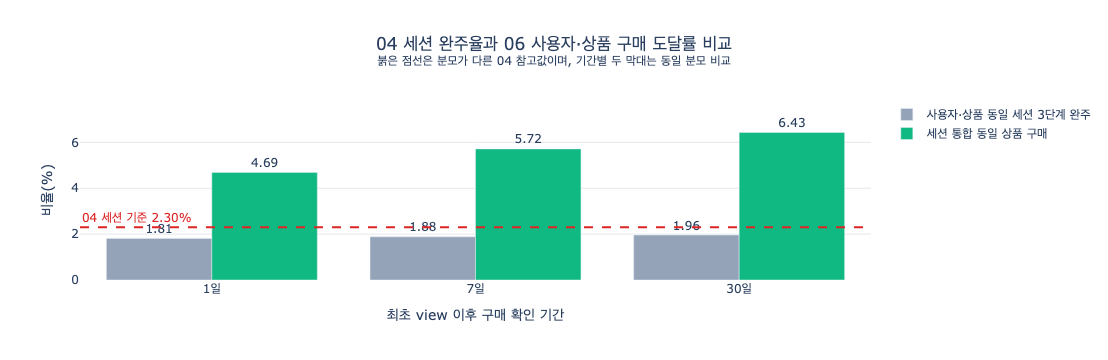

In [8]:
metric_comparison = window_comparison.melt(
    id_vars=['구매확인기간', '구매판정가능_사용자상품수'],
    value_vars=[
        '동일세션_view_cart_purchase완주율_pct',
        '세션통합_동일상품구매도달률_pct',
    ],
    var_name='지표',
    value_name='비율_pct',
).rename(columns={
    '구매확인기간': '비교구간',
    '구매판정가능_사용자상품수': '분모수',
})
metric_comparison['지표'] = metric_comparison['지표'].map({
    '동일세션_view_cart_purchase완주율_pct': '사용자·상품 동일 세션 3단계 완주',
    '세션통합_동일상품구매도달률_pct': '세션 통합 동일 상품 구매',
})
metric_comparison['분모단위'] = '사용자·상품'

fig = px.bar(
    metric_comparison,
    x='비교구간',
    y='비율_pct',
    color='지표',
    barmode='group',
    text_auto='.2f',
    custom_data=['분모수', '분모단위'],
    category_orders={
        '비교구간': ['1일', '7일', '30일'],
        '지표': [
            '사용자·상품 동일 세션 3단계 완주',
            '세션 통합 동일 상품 구매',
        ],
    },
    color_discrete_map={
        '사용자·상품 동일 세션 3단계 완주': '#94A3B8',
        '세션 통합 동일 상품 구매': color_map['purchase'],
    },
    title=(
        '04 세션 완주율과 06 사용자·상품 구매 도달률 비교<br>'
        '<sup>붉은 점선은 분모가 다른 04 참고값이며, 기간별 두 막대는 동일 분모 비교</sup>'
    ),
)
fig.add_hline(
    y=benchmark_rate,
    line_dash='dash',
    line_color='#DC2626',
    line_width=2,
    annotation_text=f'04 세션 기준 {benchmark_rate:.2f}%',
    annotation_position='top left',
    annotation_font_color='#DC2626',
)
fig.update_traces(
    textposition='outside',
    hovertemplate='%{x} · %{fullData.name}<br>%{y:.3f}%<br>분모 %{customdata[0]:,.0f} %{customdata[1]}<extra></extra>',
)
fig.update_layout(
    title_x=0.5,
    yaxis_title='비율(%)',
    xaxis_title='최초 view 이후 구매 확인 기간',
    yaxis_range=[0, metric_comparison['비율_pct'].max() * 1.22],
    plot_bgcolor='white',
    legend_title_text='',
)
fig.update_yaxes(gridcolor='#E5E7EB')
fig.show()

> ### 검토 가설 1 관찰 결과
>
> **비즈니스 질문.** 동일 세션의 `view → cart → purchase`만 전환으로 정의하면 사용자·상품 관점의 구매 도달을 얼마나 놓치는가?
>
> **검토 가설 1.** 사용자·상품의 구매 경로에는 세션 간 구매와 cart 미경유 구매가 포함된다. 따라서 동일한 사용자·상품 분모에서도 세션 통합 N일 동일 상품 구매 도달률은 같은 세션 3단계 완주율보다 높게 나타날 것이다.
>
> **핵심 결과: 최초 view 후 30일 구매가 확인된 사용자·상품 342,457개 중 238,094개(69.53%)는 동일 세션 3단계 밖에서 관찰됐다.**
>
> 30일 구매 여부를 판정할 수 있는 공통 분모는 5,323,764개이며, 같은 세션 3단계 완주는 104,363개(1.960%), 세션 통합 동일 상품 구매는 342,457개(6.433%)였다.
>
> | 관측 창 | 같은 세션 3단계 완주율 | 세션 통합 구매 도달률 | 격차 |
> |---|---:|---:|---:|
> | 1일 | 1.815% | 4.692% | 2.878%p |
> | 7일 | 1.881% | 5.715% | 3.835%p |
> | 30일 | 1.960% | 6.433% | 4.472%p |
>
> - 세션 통합 구매가 더 큰 방향은 포함 관계상 구조적으로 예상된다. 핵심은 방향보다 **동일 세션 3단계 밖 구매의 규모**다. 다만 관측 창별 판정 가능 모집단이 달라 격차의 시간 추세는 판단하지 않는다.
> - 04의 2.299%는 상품 동일성을 요구하지 않는 세션 단위 지표다. 사용자·상품 단위인 본 섹션 값과 직접 비교하지 않으며 참고 기준으로만 제시한다.
> - 차이에는 세션 간 구매뿐 아니라 cart 미경유·순서 미확인 경로도 포함된다. 또한 30일 우측 절단 조합은 1,383,629개(20.63%), 다중 purchase 경계 주의 조합은 242개다.

---
## 2. 구매 차수에 따라 구매 전 경로가 어떻게 달라지는가

**비즈니스 질문.** 05에서 확인한 현재 purchase 세션 밖의 동일 상품 cart를 실제 이벤트 시각으로 다시 연결하면, 구매 차수별 경로는 어떻게 달라지는가?

**검토 가설 2.** 이전 동일 상품 구매보다 앞선 행동을 이번 구매에서 제외한 뒤에도 `다른 세션 cart → 현재 purchase`가 가장 큰 구매 경로일 것이다.

**가설 수립 근거 — `05_purchase_journey_eda.ipynb` §3·본 노트북 §1.** 본 노트북 §1에서 30일 동일 상품 구매의 69.53%가 같은 세션 3단계 밖에서 확인돼 경로 확장의 필요성이 나타났다. 05 §3에서는 같은 세션 3단계가 확인되지 않은 purchase 중 556,137개(51.04%)에 이전에 끝난 동일 상품 cart가 있었다. 두 모집단을 직접 비교하지 않고, 전체 구매로 분모를 넓히고 이전 purchase보다 오래된 행동을 제외한 뒤에도 다른 세션 cart 연결이 가장 큰 경로로 남을지 확인한다.

**판정 기준.** 배타적으로 나눈 여섯 경로 중 `다른 세션 cart → 현재 purchase`의 구매 세션·상품 수가 가장 큰지 확인한다.

분석 단위는 purchase가 있는 세션·상품이다. 각 구매보다 먼저 발생한 가장 가까운 동일 상품 view·cart를 찾는다. 같은 상품의 이전 구매가 있다면 그 구매보다 앞선 행동은 이번 구매에 다시 연결하지 않는다. 관측 기간에 이전 구매가 없으면 **관측 첫 구매**, 있으면 **관측 반복 구매**로 구분하고, 구매 차수와 구매 전 경로는 별도로 보존한다.

이번 구매에 연결할 행동 구간은 아래처럼 이전 구매와 현재 구매 사이로 제한한다.

```text
이전 purchase │ 이번 구매에 연결할 view·cart │ 현재 purchase
              └─ 이 구간 안의 행동만 사용 ─┘
```

이 구간 안에서 현재 purchase와 같은 `user_session`의 행동은 `현재 구매 세션`, 다른 `user_session`의 행동은 `다른 세션`으로 표시한다. `다른 세션`은 바로 직전 세션이라는 뜻이 아니라, 현재 purchase보다 앞선 행동이 현재 구매 세션과 다른 세션에 기록됐다는 뜻이다.

`구매 전 cart 미확인`은 cart 이벤트가 데이터 전체에 없다는 뜻이 아니다. 이전 구매보다 앞선 cart나 현재 구매보다 늦은 cart는 이번 구매에 연결하지 않는다. 남은 view·cart의 세션과 순서를 기준으로 각 구매에 겹치지 않는 경로 하나만 부여한다.

In [9]:
paths = run('pj_purchase_paths').copy()  # 05 §3의 미확정 purchase를 구매 차수와 겹치지 않는 경로로 분리(구매 세션·상품 단위, §3·§4에도 재사용)
paths['구매경로'] = paths['구매경로'].replace({
    '같은 세션 view→cart→purchase': '현재 구매 세션 view→cart→purchase',
    '이전 세션 cart→현재 purchase': '다른 세션 cart→현재 purchase',
    '같은 세션 cart→purchase': '현재 구매 세션 cart→purchase',
    '이전 세션 view→현재 purchase': '다른 세션 view→현재 purchase',
    '같은 세션 view→purchase': '현재 구매 세션 view→purchase',
    '선행 view·cart 미확인': '구매 전 view·cart 미확인',
})
display(paths)

[pj_purchase_paths] 캐시 로드 · 32행


,구매차수,구매경로,카테고리구분,사용자유형,구매_세션상품수,purchase_이벤트수,revenue,다중purchase_세션상품수
0,관측 반복 구매,구매 전 view·cart 미확인,04 우선진단 카테고리,2+세션 사용자,28,29.0,2482.29,1.0
1,관측 반복 구매,구매 전 view·cart 미확인,그 외 카테고리,2+세션 사용자,10582,10767.0,47135.62,185.0
2,관측 반복 구매,다른 세션 cart→현재 purchase,04 우선진단 카테고리,2+세션 사용자,18,18.0,1643.29,0.0
3,관측 반복 구매,다른 세션 cart→현재 purchase,그 외 카테고리,2+세션 사용자,15370,15448.0,89091.06,74.0
4,관측 반복 구매,다른 세션 view→현재 purchase,04 우선진단 카테고리,2+세션 사용자,4,4.0,552.38,0.0
5,관측 반복 구매,다른 세션 view→현재 purchase,그 외 카테고리,2+세션 사용자,1141,1153.0,5319.48,12.0
6,관측 반복 구매,현재 구매 세션 cart→purchase,04 우선진단 카테고리,2+세션 사용자,39,42.0,3681.14,2.0
7,관측 반복 구매,현재 구매 세션 cart→purchase,그 외 카테고리,2+세션 사용자,16582,16786.0,97257.70,196.0
8,관측 반복 구매,현재 구매 세션 view→cart→purchase,04 우선진단 카테고리,2+세션 사용자,21,21.0,1844.21,0.0
9,관측 반복 구매,현재 구매 세션 view→cart→purchase,그 외 카테고리,2+세션 사용자,3445,3491.0,26003.95,45.0


In [10]:
scope = journey_scope.iloc[0]
assert int(paths['구매_세션상품수'].sum()) == int(scope['구매_세션상품수'])
assert int(paths['purchase_이벤트수'].sum()) == int(scope['purchase_이벤트수'])
assert int(paths['다중purchase_세션상품수'].sum()) == int(scope['다중purchase_세션상품수'])
print(
    f"합계 검증 통과 · 구매 세션·상품 {int(scope['구매_세션상품수']):,} · "
    f"purchase 이벤트 {int(scope['purchase_이벤트수']):,} · "
    f"다중 purchase 세션·상품 {int(scope['다중purchase_세션상품수']):,}"
)

합계 검증 통과 · 구매 세션·상품 1,221,747 · purchase 이벤트 1,229,578 · 다중 purchase 세션·상품 7,608


#### 구매 차수별 경로 구성

관측 첫 구매와 관측 반복 구매 안에서 각 구매 경로가 차지하는 규모와 비율을 확인한다.

In [11]:
path_overall = (
    paths.groupby(['구매차수', '구매경로'], as_index=False)['구매_세션상품수'].sum()
)
path_overall['구매차수내_비율_pct'] = (
    path_overall['구매_세션상품수']
    / path_overall.groupby('구매차수')['구매_세션상품수'].transform('sum') * 100
)
display(path_overall.round(2))

,구매차수,구매경로,구매_세션상품수,구매차수내_비율_pct
0,관측 반복 구매,구매 전 view·cart 미확인,10610,22.15
1,관측 반복 구매,다른 세션 cart→현재 purchase,15388,32.13
2,관측 반복 구매,다른 세션 view→현재 purchase,1145,2.39
3,관측 반복 구매,현재 구매 세션 cart→purchase,16621,34.70
4,관측 반복 구매,현재 구매 세션 view→cart→purchase,3466,7.24
5,관측 반복 구매,현재 구매 세션 view→purchase,663,1.38
6,관측 첫 구매,구매 전 view·cart 미확인,77024,6.56
7,관측 첫 구매,다른 세션 cart→현재 purchase,500006,42.60
8,관측 첫 구매,다른 세션 view→현재 purchase,17982,1.53
9,관측 첫 구매,현재 구매 세션 cart→purchase,437508,37.27


#### 구매 경로별 전체 규모

구매 차수를 합쳐 각 구매 경로가 전체 구매 세션·상품에서 차지하는 규모를 확인한다.

In [12]:
path_summary = path_overall.groupby('구매경로', as_index=False)['구매_세션상품수'].sum()
path_summary['전체구매내_비율_pct'] = (
    path_summary['구매_세션상품수'] / path_summary['구매_세션상품수'].sum() * 100
)
display(path_summary.sort_values('구매_세션상품수', ascending=False).round(2))

,구매경로,구매_세션상품수,전체구매내_비율_pct
1,다른 세션 cart→현재 purchase,515394,42.19
3,현재 구매 세션 cart→purchase,454129,37.17
4,현재 구매 세션 view→cart→purchase,131793,10.79
0,구매 전 view·cart 미확인,87634,7.17
2,다른 세션 view→현재 purchase,19127,1.57
5,현재 구매 세션 view→purchase,13670,1.12


#### 관측 구매 차수별 규모

전체 구매 세션·상품을 관측 첫 구매와 관측 반복 구매로 나눠 모집단 크기를 확인한다.

In [13]:
purchase_order_summary = path_overall.groupby('구매차수', as_index=False)['구매_세션상품수'].sum()
purchase_order_summary['전체구매내_비율_pct'] = (
    purchase_order_summary['구매_세션상품수']
    / purchase_order_summary['구매_세션상품수'].sum() * 100
)
display(purchase_order_summary.round(2))

,구매차수,구매_세션상품수,전체구매내_비율_pct
0,관측 반복 구매,47893,3.92
1,관측 첫 구매,1173854,96.08


#### 사용자 유형별 규모

구매 세션·상품이 1세션 사용자와 2+세션 사용자 중 어디에 분포하는지 확인한다.

In [14]:
user_type_summary = paths.groupby('사용자유형', as_index=False)['구매_세션상품수'].sum()
user_type_summary['전체구매내_비율_pct'] = (
    user_type_summary['구매_세션상품수'] / user_type_summary['구매_세션상품수'].sum() * 100
)
display(user_type_summary.round(2))

,사용자유형,구매_세션상품수,전체구매내_비율_pct
0,1세션 사용자,120047,9.83
1,2+세션 사용자,1101700,90.17


#### 구매 전 행동 확인 범위

배타적 구매 경로를 구매 전 cart 확인, view만 확인, view·cart 미확인으로 다시 묶어 전체 합계를 검증한다.

In [15]:
view_only_paths = ['다른 세션 view→현재 purchase', '현재 구매 세션 view→purchase']
view_only_n = int(
    path_summary.loc[path_summary['구매경로'].isin(view_only_paths), '구매_세션상품수'].sum()
)
cart_confirmed_paths = [
    '현재 구매 세션 view→cart→purchase',
    '다른 세션 cart→현재 purchase',
    '현재 구매 세션 cart→purchase',
]
cart_confirmed_n = int(
    path_summary.loc[path_summary['구매경로'].isin(cart_confirmed_paths), '구매_세션상품수'].sum()
)
no_prior_n = int(
    path_summary.loc[
        path_summary['구매경로'] == '구매 전 view·cart 미확인', '구매_세션상품수'
    ].sum()
)
assert cart_confirmed_n + view_only_n + no_prior_n == int(scope['구매_세션상품수'])
print(f'cart 선행 확인 경로 = {cart_confirmed_n:,} ({cart_confirmed_n / int(scope["구매_세션상품수"]) * 100:.2f}%)')
print(f'구매 전 cart 없이 view만 확인된 경로 = {view_only_n:,} ({view_only_n / int(scope["구매_세션상품수"]) * 100:.2f}%)')
print(f'구매 전 view·cart 미확인 = {no_prior_n:,} ({no_prior_n / int(scope["구매_세션상품수"]) * 100:.2f}%)')

cart 선행 확인 경로 = 1,101,316 (90.14%)
구매 전 cart 없이 view만 확인된 경로 = 32,797 (2.68%)
구매 전 view·cart 미확인 = 87,634 (7.17%)


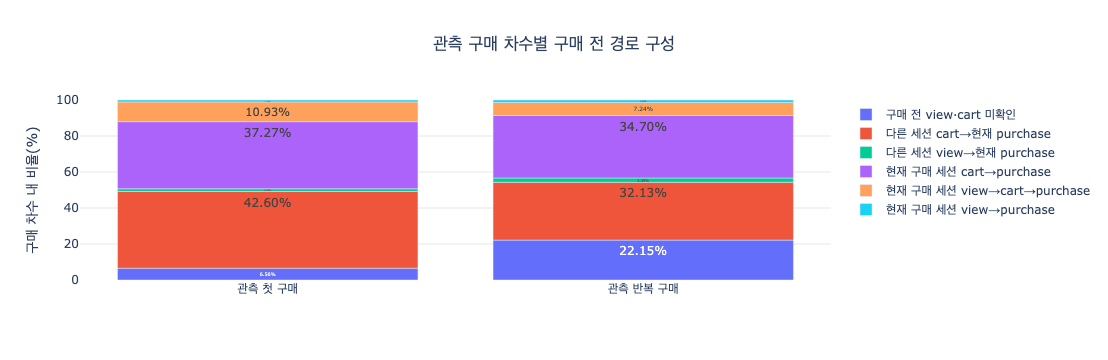

In [16]:
fig = px.bar(
    path_overall,
    x='구매차수',
    y='구매차수내_비율_pct',
    color='구매경로',
    text_auto='.2f',
    custom_data=['구매_세션상품수'],
    category_orders={'구매차수': ['관측 첫 구매', '관측 반복 구매']},
    title='관측 구매 차수별 구매 전 경로 구성',
)
fig.update_traces(
    texttemplate='%{y:.2f}%',
    textposition='inside',
    hovertemplate='%{x} · %{fullData.name}<br>%{y:.2f}%<br>%{customdata[0]:,.0f}개<extra></extra>',
)
fig.update_layout(
    title_x=0.5,
    yaxis_title='구매 차수 내 비율(%)',
    xaxis_title='',
    yaxis_range=[0, 100],
    plot_bgcolor='white',
    legend_title_text='',
)
fig.update_yaxes(gridcolor='#E5E7EB')
fig.show()

> ### 검토 가설 2 관찰 결과
>
> **검토 가설 2.** 이전 동일 상품 구매보다 앞선 행동을 제외한 뒤에도 `다른 세션 cart → 현재 purchase`가 가장 큰 구매 경로일 것이다.
>
> **핵심 결과: `다른 세션 cart → 현재 purchase`가 전체 구매 세션·상품의 42.19%로 가장 크게 나타나 관찰 데이터가 가설의 예상 방향과 일치했다.**
>
> | 비교 항목 | 구매 세션·상품 수 | 전체 구매 내 비율 | 차이 |
> |---|---:|---:|---:|
> | **1위 · 다른 세션 cart → 현재 purchase** | **515,394** | **42.19%** | **+5.01%p** |
> | 2위 · 현재 구매 세션 cart → purchase | 454,129 | 37.17% | 기준 |
>
> - 서로 겹치지 않게 나눈 여섯 경로 중 다른 세션 cart 연결이 가장 컸다. 다만 현재 구매 세션 cart 연결과의 차이는 5.01%p이므로 두 경로가 전체 구매의 큰 축으로 함께 관찰됐다.
> - 다른 세션 cart 연결 비중은 관측 첫 구매 **42.60%**·관측 반복 구매 **32.13%** 로 **10.47%p** 차이 났다. 이 차이가 어느 경로에 나타나는지는 아래 분석 질문 2-1에서 확대한다.
> - `다른 세션 cart → 현재 purchase`는 이전 구매 이후의 가장 가까운 cart를 연결한 관찰 경로다. 장바구니 유지나 리마인드 효과를 직접 입증하는 값은 아니다.

### 2.1. 구매 전 cart 확인 여부로 경로 차이를 확대한다

**분석 질문 2-1.** 관측 첫 구매와 관측 반복 구매의 구매 전 cart 미확인 비중은 얼마나 다르며, 그 차이는 어느 세부 경로에 집중되는가?

**후속 질문 근거와 해석 범위 — 본 노트북 §2 가설 관찰 결과.** 다른 세션 cart 연결 비중이 관측 첫 구매 42.60%·반복 구매 32.13%로 차이 나, 나머지 비중이 어느 경로에 있는지 확인한다. 재주문 진입 로그가 없고 반복 구매의 행동 탐색 구간도 더 짧을 수 있으므로 방향 가설로 판정하지 않고 격차의 크기와 위치만 기술한다.

같은 여섯 경로를 `구매 전 cart 확인`과 `구매 전 cart 미확인`으로 다시 묶고, 미확인을 `다른 세션 view`, `현재 구매 세션 view`, `view·cart 모두 미확인`으로 나눠 차이의 위치를 확인한다.

분석 단위는 동일하게 purchase가 있는 세션·상품이다. `구매 전 cart 미확인`은 이전 구매 이후부터 현재 구매 전까지 cart를 찾지 못했다는 뜻이며, 실제 cart 미경유뿐 아니라 관측 시작 이전 행동과 로그 누락도 포함할 수 있다.

In [17]:
path_cart_status = path_overall.copy()
path_cart_status['구매전_cart구분'] = np.where(
    path_cart_status['구매경로'].isin(cart_confirmed_paths),
    '구매 전 cart 확인',
    '구매 전 cart 미확인',
)
cart_by_purchase_order = (
    path_cart_status.groupby(['구매차수', '구매전_cart구분'], as_index=False)['구매_세션상품수'].sum()
)
cart_by_purchase_order['구매차수내_비율_pct'] = (
    cart_by_purchase_order['구매_세션상품수']
    / cart_by_purchase_order.groupby('구매차수')['구매_세션상품수'].transform('sum') * 100
)
assert (
    cart_by_purchase_order.groupby('구매차수')['구매차수내_비율_pct'].sum().round(10) == 100
).all()
assert int(cart_by_purchase_order['구매_세션상품수'].sum()) == int(scope['구매_세션상품수'])
display(cart_by_purchase_order.round(2))

missing_cart_rate = cart_by_purchase_order[
    cart_by_purchase_order['구매전_cart구분'] == '구매 전 cart 미확인'
].set_index('구매차수')['구매차수내_비율_pct']
first_missing_rate = float(missing_cart_rate['관측 첫 구매'])
repeat_missing_rate = float(missing_cart_rate['관측 반복 구매'])
print(
    f'구매 전 cart 미확인 비중 · 관측 첫 구매 {first_missing_rate:.2f}% · '
    f'관측 반복 구매 {repeat_missing_rate:.2f}% · '
    f'차이 {repeat_missing_rate - first_missing_rate:.2f}%p · '
    f'수치상 {repeat_missing_rate / first_missing_rate:.2f}배'
)

,구매차수,구매전_cart구분,구매_세션상품수,구매차수내_비율_pct
0,관측 반복 구매,구매 전 cart 미확인,12418,25.93
1,관측 반복 구매,구매 전 cart 확인,35475,74.07
2,관측 첫 구매,구매 전 cart 미확인,108013,9.20
3,관측 첫 구매,구매 전 cart 확인,1065841,90.80


구매 전 cart 미확인 비중 · 관측 첫 구매 9.20% · 관측 반복 구매 25.93% · 차이 16.73%p · 수치상 2.82배


#### 핵심 비율 차이 요약

결론에서 비교하는 비율 차이를 직접 확인한다. 각 행의 `차이`는 `대상 1 비율 - 대상 2 비율`이며, 비율의 분모는 `분모` 열에 명시한다.

In [18]:
path_rates = path_summary.set_index('구매경로')['전체구매내_비율_pct']
cross_cart_rates = (
    path_overall[path_overall['구매경로'] == '다른 세션 cart→현재 purchase']
    .set_index('구매차수')['구매차수내_비율_pct']
)
cart_missing_rates = missing_cart_rate

path_gap_summary = pd.DataFrame({
    '비교지표': ['구매 경로 1·2위', '다른 세션 cart 비중', '구매 전 cart 미확인 비중'],
    '분모': ['전체 구매 세션·상품', '각 구매차수', '각 구매차수'],
    '대상1': ['다른 세션 cart', '관측 첫 구매', '관측 반복 구매'],
    '대상1_비율_pct': [
        path_rates['다른 세션 cart→현재 purchase'],
        cross_cart_rates['관측 첫 구매'],
        cart_missing_rates['관측 반복 구매'],
    ],
    '대상2': ['현재 세션 cart', '관측 반복 구매', '관측 첫 구매'],
    '대상2_비율_pct': [
        path_rates['현재 구매 세션 cart→purchase'],
        cross_cart_rates['관측 반복 구매'],
        cart_missing_rates['관측 첫 구매'],
    ],
})
path_gap_summary['대상1_minus_대상2_pctp'] = (
    path_gap_summary['대상1_비율_pct'] - path_gap_summary['대상2_비율_pct']
)
display(path_gap_summary.round(2))

,비교지표,분모,대상1,대상1_비율_pct,대상2,대상2_비율_pct,대상1_minus_대상2_pctp
0,구매 경로 1·2위,전체 구매 세션·상품,다른 세션 cart,42.19,현재 세션 cart,37.17,5.01
1,다른 세션 cart 비중,각 구매차수,관측 첫 구매,42.60,관측 반복 구매,32.13,10.47
2,구매 전 cart 미확인 비중,각 구매차수,관측 반복 구매,25.93,관측 첫 구매,9.20,16.73


#### 구매 전 cart 미확인의 세부 경로

구매 전 cart가 확인되지 않은 경로를 view 확인 위치와 view·cart 모두 미확인으로 나눠 차이의 구성을 확인한다.

In [19]:
cart_missing_paths = [
    '다른 세션 view→현재 purchase',
    '현재 구매 세션 view→purchase',
    '구매 전 view·cart 미확인',
]
cart_missing_detail = path_overall[
    path_overall['구매경로'].isin(cart_missing_paths)
][['구매차수', '구매경로', '구매_세션상품수', '구매차수내_비율_pct']].copy()
display(cart_missing_detail.round(2))

,구매차수,구매경로,구매_세션상품수,구매차수내_비율_pct
0,관측 반복 구매,구매 전 view·cart 미확인,10610,22.15
2,관측 반복 구매,다른 세션 view→현재 purchase,1145,2.39
5,관측 반복 구매,현재 구매 세션 view→purchase,663,1.38
6,관측 첫 구매,구매 전 view·cart 미확인,77024,6.56
8,관측 첫 구매,다른 세션 view→현재 purchase,17982,1.53
11,관측 첫 구매,현재 구매 세션 view→purchase,13007,1.11


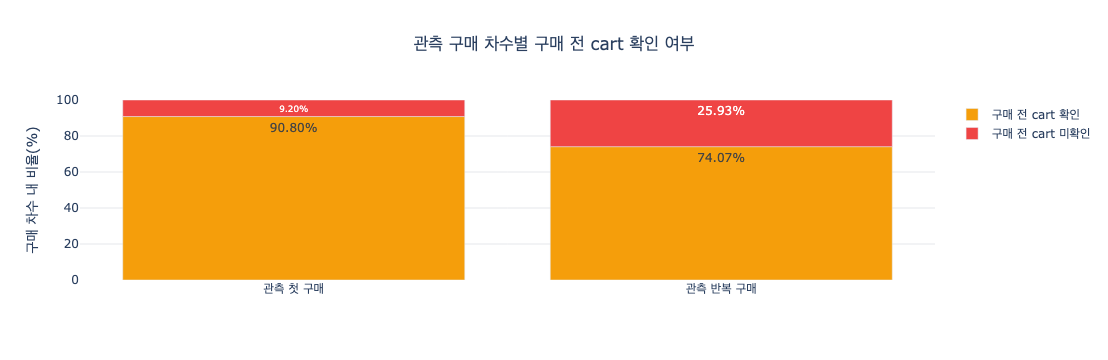

In [20]:
fig = px.bar(
    cart_by_purchase_order,
    x='구매차수',
    y='구매차수내_비율_pct',
    color='구매전_cart구분',
    text_auto='.2f',
    custom_data=['구매_세션상품수'],
    category_orders={
        '구매차수': ['관측 첫 구매', '관측 반복 구매'],
        '구매전_cart구분': ['구매 전 cart 확인', '구매 전 cart 미확인'],
    },
    color_discrete_map={
        '구매 전 cart 확인': color_map['cart'],
        '구매 전 cart 미확인': '#EF4444',
    },
    title='관측 구매 차수별 구매 전 cart 확인 여부',
)
fig.update_traces(
    texttemplate='%{y:.2f}%',
    textposition='inside',
    hovertemplate='%{x} · %{fullData.name}<br>%{y:.2f}%<br>%{customdata[0]:,.0f}개<extra></extra>',
)
fig.update_layout(
    title_x=0.5,
    yaxis_title='구매 차수 내 비율(%)',
    xaxis_title='',
    yaxis_range=[0, 100],
    plot_bgcolor='white',
    legend_title_text='',
)
fig.update_yaxes(gridcolor='#E5E7EB')
fig.show()

In [21]:
multi = paths[['구매_세션상품수', '다중purchase_세션상품수']].sum()
print(
    f"다중 purchase 세션·상품 = {int(multi['다중purchase_세션상품수']):,} / "
    f"{int(multi['구매_세션상품수']):,} "
    f"({multi['다중purchase_세션상품수'] / multi['구매_세션상품수'] * 100:.3f}%)"
)

다중 purchase 세션·상품 = 7,608 / 1,221,747 (0.623%)


> ### 분석 질문 2-1 관찰 결과
>
> **분석 질문 2-1.** 관측 첫 구매와 관측 반복 구매의 구매 전 cart 미확인 비중은 얼마나 다르며, 그 차이는 어느 세부 경로에 집중되는가?
>
> **핵심 결과 — 구매 전 cart 미확인 비중은 관측 첫 구매 9.20%·관측 반복 구매 25.93%로 16.73%p 차이 났다.** 방향을 판정하지 않고 차이가 어느 세부 경로에 집중되는지 확인한다.
>
> | 구매 차수 | 구매 세션·상품 | 구매 전 cart 확인 | 구매 전 cart 미확인 |
> |---|---:|---:|---:|
> | 관측 첫 구매 | 1,173,854 | 1,065,841 (90.80%) | 108,013 (9.20%) |
> | 관측 반복 구매 | 47,893 | 35,475 (74.07%) | **12,418 (25.93%)** |
>
> 구매 전 cart 미확인 108,013개와 12,418개를 세부 경로로 나누면 다음과 같다.
>
> | cart 미확인 세부 경로 | 관측 첫 구매 | 관측 반복 구매 |
> |---|---:|---:|
> | 다른 세션 view → 현재 purchase | 17,982 (1.53%) | 1,145 (2.39%) |
> | 현재 구매 세션 view → purchase | 13,007 (1.11%) | 663 (1.38%) |
> | 구매 전 view·cart 미확인 | 77,024 (6.56%) | **10,610 (22.15%)** |
>
> - 분석 질문 2-1에서는 반복 구매에서 낮아진 다른 세션 cart 비중과 구매 전 cart 미확인 증가가 함께 관찰됐다. 특히 view만 확인된 두 경로보다 `구매 전 view·cart 미확인`이 관측 반복 구매 22.15%·관측 첫 구매 6.56%로 크게 벌어져 차이의 중심으로 나타났다.
> - 다만 관측 첫 구매는 관측 시작부터 현재 purchase까지 행동을 찾고, 관측 반복 구매는 직전 동일 상품 purchase 이후부터 현재 purchase까지만 찾는다. 반복 구매의 행동 탐색 구간이 더 짧을 수 있으므로 25.93%와 9.20%의 차이를 구매 차수만의 영향으로 해석하지 않는다.
> - 관측 반복 구매는 전체 구매 세션·상품의 3.92%인 47,893개다. 상대적인 비중 차이는 크지만 절대 모집단은 관측 첫 구매보다 작으므로, 프로젝트의 최우선 개선 대상보다는 반복 구매 경로를 별도로 계측할 필요를 보여주는 보조 신호로 사용한다.
> - 구매 전 cart 미확인은 이번 구매 행동 구간에서 cart를 찾지 못했다는 뜻이다. 실제 직접 구매·재주문 경로뿐 아니라 로그 누락과 관측 범위 밖 행동이 포함될 수 있어, 반복 구매자가 cart를 건너뛴다고 확정하지 않는다. 구매 진입 화면·재주문 기능·주문내역 경로 로그를 추가해야 원인을 구분할 수 있다.
> - 관측 첫·반복 구매는 2019-10-01부터 2020-02-29까지의 구분이다. 한 세션·상품에 purchase가 여러 건인 7,608개(0.623%)는 최초 purchase를 기준으로 대표 경로 하나만 붙였기 때문에 구매 이벤트마다 경로를 완전히 나누지는 못한다.

---
## 3. 다른 세션 cart에서 purchase까지 실제로 얼마나 걸리는가

**검토 가설 3.** §2에서 확인한 `다른 세션 cart → 현재 purchase` 경로의 실제 cart→purchase 시각 차이는 24시간 미만에 과반이 분포할 것이다.

**가설 수립 근거 — `05_purchase_journey_eda.ipynb` §4·본 노트북 §2.** 본 노트북 §2에서 다른 세션 cart 연결이 515,394개(42.19%)로 가장 큰 구매 경로임을 확인했다. 05 §4에서는 이전 세션의 동일 상품 `view → cart`와 현재 세션 purchase가 연결된 138,796개 중, 두 세션 사이의 빈 시간이 24시간 미만인 조합이 80,201개(57.78%)였다. 이 선행 관찰에서 단기 구간이 과반이었으므로, 실제 이벤트 시각으로 다시 측정하는 가설 3도 24시간 미만 50%를 확인 기준으로 둔다. 단, 05의 57.78%는 가설 수립을 위한 참고 근거일 뿐 06 결과와 직접 대조하는 기준값은 아니다.

**판정 기준.** 전체 515,394개 구매 에피소드 중 실제 cart→purchase 시각 차이가 24시간 미만인 비중이 50%를 넘으면 가설을 확인한다.

05의 138,796개는 이전에 끝난 `view → cart` 세션을 기준으로 했고, 06의 515,394개는 이전 purchase 이후 가장 가까운 다른 세션 cart를 기준으로 한다. 모집단·연결 규칙·기간 구간 경계가 다르므로 05의 24시간 미만 57.78%·7일 범위 누적 84.04%와 06 결과를 같은 지표의 전후 값으로 직접 비교하지 않는다.

분석 단위는 구매 에피소드다. 05의 세션 종료→다음 세션 시작 간격이 아니라, 이전 purchase 이후 가장 가까운 동일 상품 cart 이벤트 시각과 현재 최초 purchase 이벤트 시각의 차이를 계산한다. 가장 가까운 cart가 현재 구매 세션에 있으면 제외해, 다른 `user_session`에서 발생한 cart 연결만 남긴다.

In [22]:
delay = run('pj_cross_session_cart_delay')  # 05 §4의 세션 간격을 실제 cart→purchase 시각차로 보완(구매 에피소드 단위, §2 다른 세션 cart 경로와 대조)
delay_total = delay.groupby('구매차수')['구매에피소드수'].sum().sort_index()
path_delay_total = (
    path_overall[path_overall['구매경로'] == '다른 세션 cart→현재 purchase']
    .set_index('구매차수')['구매_세션상품수'].sort_index()
)
assert delay_total.equals(path_delay_total)

delay_24h_bins = ['1시간 미만', '1-6시간', '6-12시간', '12-24시간']
delay_24h_width = {'1시간 미만': 1, '1-6시간': 5, '6-12시간': 6, '12-24시간': 12}
delay_order = delay_24h_bins + ['1-3일', '4-7일', '8-14일', '15-30일', '31일 이상']
purchase_order = ['관측 첫 구매', '관측 반복 구매']
delay['구매차수'] = pd.Categorical(delay['구매차수'], purchase_order, ordered=True)
delay['기간구간'] = pd.Categorical(delay['기간구간'], delay_order, ordered=True)
delay = delay.sort_values(['구매차수', '기간구간']).reset_index(drop=True)
delay['구매차수내_비율_pct'] = (
    delay['구매에피소드수'] / delay.groupby('구매차수', observed=True)['구매에피소드수'].transform('sum') * 100
)
delay['누적비율_pct'] = delay.groupby('구매차수', observed=True)['구매차수내_비율_pct'].cumsum()

[pj_cross_session_cart_delay] 캐시 로드 · 18행


In [23]:
delay_overall = delay.groupby(
    '기간구간', as_index=False, observed=True
)['구매에피소드수'].sum()
delay_overall['기간구간'] = pd.Categorical(
    delay_overall['기간구간'], delay_order, ordered=True
)
delay_overall = delay_overall.sort_values('기간구간').reset_index(drop=True)
delay_overall['전체비율_pct'] = (
    delay_overall['구매에피소드수'] / delay_overall['구매에피소드수'].sum() * 100
)
delay_overall['누적비율_pct'] = delay_overall['전체비율_pct'].cumsum()

overall_total = int(delay_overall['구매에피소드수'].sum())
delay_hypothesis_rows = []
for label, bins in [
    ('24시간 미만', delay_24h_bins),
    ('3일 미만', delay_24h_bins + ['1-3일']),
    ('7일 미만', delay_24h_bins + ['1-3일', '4-7일']),
    ('14일 미만', delay_24h_bins + ['1-3일', '4-7일', '8-14일']),
    ('30일 미만', delay_24h_bins + ['1-3일', '4-7일', '8-14일', '15-30일']),
    ('전체', delay_order),
]:
    count = int(delay_overall.loc[delay_overall['기간구간'].isin(bins), '구매에피소드수'].sum())
    delay_hypothesis_rows.append({
        '누적기준': label,
        '구매에피소드수': count,
        '전체비율_pct': count / overall_total * 100,
    })
delay_hypothesis_summary = pd.DataFrame(delay_hypothesis_rows)
delay_hypothesis_summary['직전기준대비_추가비중_pctp'] = (
    delay_hypothesis_summary['전체비율_pct'].diff()
)
delay_hypothesis_summary.loc[0, '직전기준대비_추가비중_pctp'] = (
    delay_hypothesis_summary.loc[0, '전체비율_pct']
)
delay_hypothesis_summary['추가구간폭_일'] = [1, 2, 4, 7, 16, np.nan]
delay_hypothesis_summary['일평균_추가비중_pctp'] = (
    delay_hypothesis_summary['직전기준대비_추가비중_pctp']
    / delay_hypothesis_summary['추가구간폭_일']
)

In [24]:
display(delay_hypothesis_summary.round(2))

,누적기준,구매에피소드수,전체비율_pct,직전기준대비_추가비중_pctp,추가구간폭_일,일평균_추가비중_pctp
0,24시간 미만,295050,57.25,57.25,1.0,57.25
1,3일 미만,378462,73.43,16.18,2.0,8.09
2,7일 미만,435848,84.57,11.13,4.0,2.78
3,14일 미만,474599,92.08,7.52,7.0,1.07
4,30일 미만,501524,97.31,5.22,16.0,0.33
5,전체,515394,100.00,2.69,NaN,NaN


In [25]:
display(delay_overall.round(2))

,기간구간,구매에피소드수,전체비율_pct,누적비율_pct
0,1시간 미만,106573,20.68,20.68
1,1-6시간,88485,17.17,37.85
2,6-12시간,35586,6.90,44.75
3,12-24시간,64406,12.50,57.25
4,1-3일,83412,16.18,73.43
5,4-7일,57386,11.13,84.57
6,8-14일,38751,7.52,92.08
7,15-30일,26925,5.22,97.31
8,31일 이상,13870,2.69,100.00


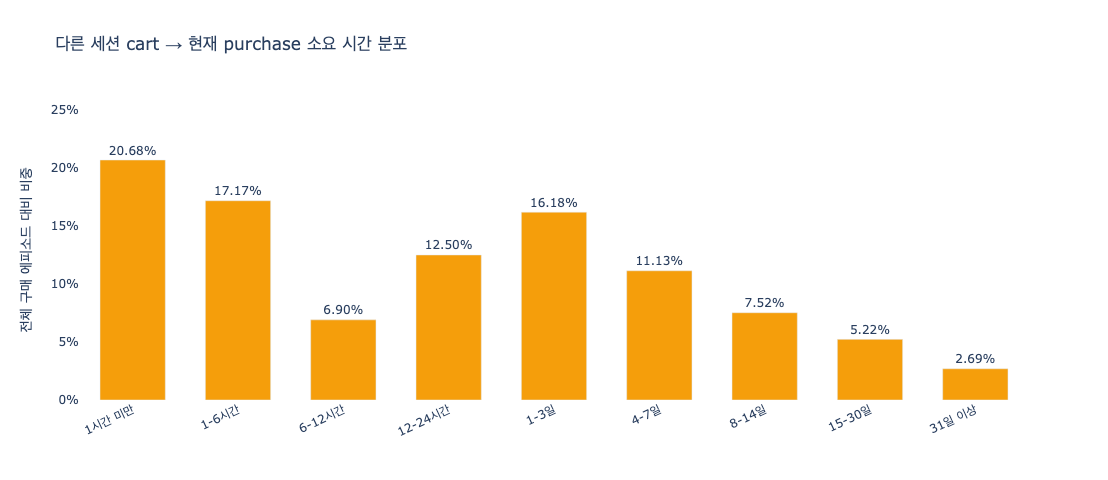

In [26]:
fig = px.bar(
    delay_overall,
    x='기간구간',
    y='전체비율_pct',
    text='전체비율_pct',
    custom_data=['구매에피소드수', '누적비율_pct'],
    category_orders={'기간구간': delay_order},
    color_discrete_sequence=[color_map['cart']],
    title='다른 세션 cart → 현재 purchase 소요 시간 분포',
)
fig.update_traces(
    width=0.62,
    texttemplate='%{text:.2f}%',
    textposition='outside',
    cliponaxis=False,
    hovertemplate=(
        '%{x}<br>전체 비중 %{y:.2f}%<br>'
        '구매 에피소드 %{customdata[0]:,.0f}<br>'
        '누적 비중 %{customdata[1]:.2f}%<extra></extra>'
    ),
)
fig.update_layout(
    yaxis_title='전체 구매 에피소드 대비 비중',
    xaxis_title='',
    yaxis_range=[0, delay_overall['전체비율_pct'].max() * 1.25],
    plot_bgcolor='white',
    bargap=0.30,
    height=480,
)
fig.update_yaxes(ticksuffix='%')
fig.update_xaxes(tickangle=-25)
fig.show()

> ### 검토 가설 3 관찰 결과
>
> **검토 가설 3.** `다른 세션 cart → 현재 purchase` 경로의 실제 cart→purchase 시각 차이는 24시간 미만에 과반이 분포할 것이다.
>
> **핵심 결과: 다른 세션 cart 연결 구매 515,394개 중 295,050개(57.25%)가 24시간 미만에 발생해 관찰 데이터가 가설의 예상 방향과 일치했다.**
>
> | 실제 cart→purchase 경과 시간 | 누적 구매 에피소드 수 | 전체 경로 내 누적 비중 |
> |---|---:|---:|
> | **24시간 미만** | **295,050** | **57.25%** |
> | 3일 미만 | 378,462 | 73.43% |
> | 7일 미만 | 435,848 | 84.57% |
>
> 추가 누적분의 구간 폭을 함께 보면 다음과 같다.
>
> | 추가 관측 구간 | 원값 기준 추가 비중 | 구간 폭 | 일평균 추가 비중 |
> |---|---:|---:|---:|
> | 1-3일 | 16.18%p | 2일 | 8.09%p/일 |
> | 4-7일 | 11.13%p | 4일 | 2.78%p/일 |
>
> 추가 비중은 반올림된 누적 비율의 차이가 아니라 구매 에피소드 원값으로 계산했다. 따라서 표시된 `84.57% - 73.43%`와 0.01%p 차이가 날 수 있다.
>
> - 24시간 미만에 57.25%가 분포했고, 이후 1-3일 구간에서 16.18%p, 4-7일 구간에서 11.13%p가 추가됐다. 구간 폭으로 단순 환산한 일평균 추가 비중은 각각 8.09%p/일·2.78%p/일로 낮아졌다. 구매가 확인된 경로에서는 시간이 지날수록 추가 발생 밀도가 낮아지는 패턴이 관찰됐으며, 이 바깥쪽 분포를 바탕으로 §3.1에서 첫 24시간 내부를 다시 세분화한다.
> - 일평균 추가 비중은 `구간 추가 비중 ÷ 구간 일수`로 계산한 단순 환산값이다. 각 날짜에 구매가 균등하게 발생했다는 뜻도 아니고, 일별 구매 전환율을 뜻하지도 않는다.
> - 31일 이상 연결도 13,870개(2.69%) 관찰됐다. 오래된 cart가 유지된 상태인지 이후 재탐색 과정의 일부인지는 장바구니 상태 로그 없이 구분할 수 없다.
> - 이 값은 최종 구매가 확인된 경로 안의 조건부 시간 분포이며 전체 cart의 구매확률을 뜻하지 않는다. 또한 05와 06은 모집단·연결 규칙이 달라 05의 24시간 미만 57.78%·7일 누적 84.04%와 직접 비교하지 않는다.

### 3.1. 24시간 안에서는 언제 구매가 집중되는가

**분석 질문 3-1.** §3에서 절반이 넘는 구매가 24시간 미만에 발생했음을 확인했다. 첫 24시간을 `1시간 미만 / 1-6시간 / 6-12시간 / 12-24시간`으로 나누면 구매는 어느 구간에 집중되며, 관측 첫 구매와 반복 구매의 분포는 어떻게 다른가?

**질문 수립 근거 — 본 노트북 §3 결과.** 24시간 미만이라는 하나의 구간만으로는 초기 자연 구매가 언제 집중되는지 구분하기 어렵다. 따라서 §3 결과에서 후속 질문을 도출해 첫 24시간 내부 분포를 세분화한다. 구매가 확인된 에피소드만을 대상으로 하므로 CRM 발송 시점의 효과를 판정하지 않고, 후속 실험의 시간대 후보를 좁히는 데 사용한다.

In [27]:
delay_24h_by_order = (
    delay[delay['기간구간'].isin(delay_24h_bins)]
    .copy()
    .reset_index(drop=True)
)
delay_24h_by_order['24시간내_구간비중_pct'] = (
    delay_24h_by_order['구매에피소드수']
    / delay_24h_by_order.groupby(
        '구매차수', observed=True
    )['구매에피소드수'].transform('sum') * 100
)
delay_24h_by_order['24시간내_누적비중_pct'] = delay_24h_by_order.groupby(
    '구매차수', observed=True
)['24시간내_구간비중_pct'].cumsum()
delay_24h_by_order['구간시간폭_시간'] = (
    delay_24h_by_order['기간구간'].astype('object').map(delay_24h_width).astype(int)
)
delay_24h_by_order['시간당평균_비중_pct'] = (
    delay_24h_by_order['24시간내_구간비중_pct'] / delay_24h_by_order['구간시간폭_시간']
)

delay_24h_overall = (
    delay_overall[delay_overall['기간구간'].isin(delay_24h_bins)]
    .copy()
    .reset_index(drop=True)
)
delay_24h_overall['24시간내_구간비중_pct'] = (
    delay_24h_overall['구매에피소드수']
    / delay_24h_overall['구매에피소드수'].sum() * 100
)
delay_24h_overall['24시간내_누적구매수'] = delay_24h_overall['구매에피소드수'].cumsum()
delay_24h_overall['24시간내_누적비중_pct'] = delay_24h_overall['24시간내_구간비중_pct'].cumsum()
delay_24h_overall['구간시간폭_시간'] = (
    delay_24h_overall['기간구간'].astype('object').map(delay_24h_width).astype(int)
)
delay_24h_overall['시간당평균_비중_pct'] = (
    delay_24h_overall['24시간내_구간비중_pct'] / delay_24h_overall['구간시간폭_시간']
)

In [28]:
delay_24h_summary_table = delay_24h_overall[[
    '기간구간', '구매에피소드수', '24시간내_구간비중_pct',
    '구간시간폭_시간', '시간당평균_비중_pct',
    '24시간내_누적구매수', '24시간내_누적비중_pct',
]].rename(columns={
    '구매에피소드수': '구간별_구매에피소드수',
    '24시간내_구간비중_pct': '구간비중_pct',
    '24시간내_누적구매수': '누적_구매에피소드수',
    '24시간내_누적비중_pct': '누적비중_pct',
})
display(delay_24h_summary_table.round(2))

,기간구간,구간별_구매에피소드수,구간비중_pct,구간시간폭_시간,시간당평균_비중_pct,누적_구매에피소드수,누적비중_pct
0,1시간 미만,106573,36.12,1,36.12,106573,36.12
1,1-6시간,88485,29.99,5,6.00,195058,66.11
2,6-12시간,35586,12.06,6,2.01,230644,78.17
3,12-24시간,64406,21.83,12,1.82,295050,100.00


In [29]:
delay_24h_overall_panel = delay_24h_overall[[
    '기간구간', '구매에피소드수', '24시간내_구간비중_pct',
    '구간시간폭_시간', '시간당평균_비중_pct',
]].copy()
delay_24h_overall_panel['구매차수'] = '전체'

delay_24h_chart = pd.concat([
    delay_24h_overall_panel,
    delay_24h_by_order[[
        '구매차수', '기간구간', '구매에피소드수',
        '24시간내_구간비중_pct', '구간시간폭_시간', '시간당평균_비중_pct',
    ]],
], ignore_index=True)
delay_24h_chart['구매차수'] = pd.Categorical(
    delay_24h_chart['구매차수'], ['전체'] + purchase_order, ordered=True
)

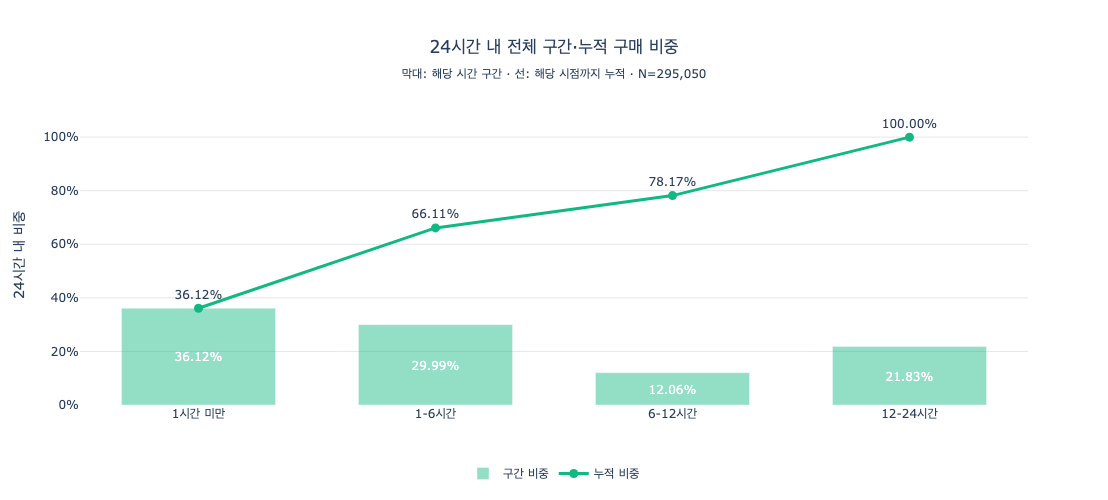

In [30]:
delay_24h_cumulative = delay_24h_overall.copy()
delay_24h_cumulative['누적시간'] = [
    '1시간 이내', '6시간 이내', '12시간 이내', '24시간 이내',
]

overall_24h_total = int(delay_24h_cumulative['구매에피소드수'].sum())

fig = go.Figure()
fig.add_trace(go.Bar(
    x=delay_24h_cumulative['기간구간'],
    y=delay_24h_cumulative['24시간내_구간비중_pct'],
    text=delay_24h_cumulative['24시간내_구간비중_pct'],
    customdata=delay_24h_cumulative[['구매에피소드수']],
    name='구간 비중',
    marker_color=color_map['purchase'],
    opacity=0.45,
    texttemplate='%{text:.2f}%',
    textposition='inside',
    insidetextanchor='middle',
    textfont=dict(color='white', size=12),
    hovertemplate=(
        '%{x}<br>해당 구간 비중 %{y:.2f}%<br>'
        '구매 에피소드 %{customdata[0]:,.0f}<extra></extra>'
    ),
))
fig.add_trace(go.Scatter(
    x=delay_24h_cumulative['기간구간'],
    y=delay_24h_cumulative['24시간내_누적비중_pct'],
    mode='lines+markers+text',
    text=delay_24h_cumulative['24시간내_누적비중_pct'],
    customdata=delay_24h_cumulative[['24시간내_누적구매수']],
    name='누적 비중',
    line=dict(color=color_map['purchase'], width=3),
    marker=dict(size=9),
    texttemplate='%{text:.2f}%',
    textposition='top center',
    hovertemplate=(
        '%{x} 구간까지<br>누적 비중 %{y:.2f}%<br>'
        '누적 구매 에피소드 %{customdata[0]:,.0f}<extra></extra>'
    ),
))
fig.update_layout(
    title=dict(
        text=(
            '24시간 내 전체 구간·누적 구매 비중<br>'
            f'<sub>막대: 해당 시간 구간 · 선: 해당 시점까지 누적 · N={overall_24h_total:,}</sub>'
        ),
        x=0.5,
        xanchor='center',
    ),
    yaxis_title='24시간 내 비중',
    xaxis_title='',
    yaxis_range=[0, 112],
    plot_bgcolor='white',
    height=500,
    bargap=0.35,
    margin=dict(t=105, b=95),
    legend_title_text='',
    legend=dict(orientation='h', y=-0.18, x=0.5, xanchor='center', yanchor='top'),
)
fig.update_yaxes(ticksuffix='%', gridcolor='#E5E7EB')
fig.show()

In [31]:
delay_24h_rate_table = delay_24h_by_order[[
    '구매차수', '기간구간', '구매에피소드수',
    '24시간내_구간비중_pct', '구간시간폭_시간',
    '시간당평균_비중_pct', '24시간내_누적비중_pct',
]]
display(delay_24h_rate_table.round(2))

,구매차수,기간구간,구매에피소드수,24시간내_구간비중_pct,구간시간폭_시간,시간당평균_비중_pct,24시간내_누적비중_pct
0,관측 첫 구매,1시간 미만,103053,35.95,1,35.95,35.95
1,관측 첫 구매,1-6시간,86161,30.05,5,6.01,66.00
2,관측 첫 구매,6-12시간,34713,12.11,6,2.02,78.11
3,관측 첫 구매,12-24시간,62759,21.89,12,1.82,100.00
4,관측 반복 구매,1시간 미만,3520,42.09,1,42.09,42.09
5,관측 반복 구매,1-6시간,2324,27.79,5,5.56,69.87
6,관측 반복 구매,6-12시간,873,10.44,6,1.74,80.31
7,관측 반복 구매,12-24시간,1647,19.69,12,1.64,100.00


In [32]:
delay_segment_cumulative = delay_24h_by_order.copy()
delay_segment_cumulative['누적시간'] = delay_segment_cumulative['기간구간'].map({
    '1시간 미만': '1시간 이내',
    '1-6시간': '6시간 이내',
    '6-12시간': '12시간 이내',
    '12-24시간': '24시간 이내',
})
delay_segment_cumulative['누적_구매에피소드수'] = delay_segment_cumulative.groupby(
    '구매차수', observed=True
)['구매에피소드수'].cumsum()

segment_color = {
    '관측 첫 구매': color_map['view'],
    '관측 반복 구매': color_map['cart'],
}
segment_total = delay_segment_cumulative.groupby(
    '구매차수', observed=True
)['구매에피소드수'].sum()

In [33]:
fig = make_subplots(
    rows=1,
    cols=2,
    shared_yaxes=True,
    horizontal_spacing=0.10,
    subplot_titles=[
        f'{label}<br><sup>24시간 내 N={segment_total[label]:,.0f}</sup>'
        for label in purchase_order
    ],
)

for col, label in enumerate(purchase_order, start=1):
    panel = delay_segment_cumulative[delay_segment_cumulative['구매차수'] == label]
    color = segment_color[label]
    fig.add_trace(
        go.Bar(
            x=panel['기간구간'],
            y=panel['24시간내_구간비중_pct'],
            text=panel['24시간내_구간비중_pct'],
            customdata=panel[['구매에피소드수']],
            name='구간 비중',
            marker_color=color,
            opacity=0.45,
            texttemplate='%{text:.2f}%',
            textposition='inside',
            insidetextanchor='middle',
            textfont=dict(color='white', size=11),
            hovertemplate=(
                '%{x}<br>해당 구간 비중 %{y:.2f}%<br>'
                '구매 에피소드 %{customdata[0]:,.0f}<extra></extra>'
            ),
            showlegend=(col == 1),
        ),
        row=1, col=col,
    )
    fig.add_trace(
        go.Scatter(
            x=panel['기간구간'],
            y=panel['24시간내_누적비중_pct'],
            mode='lines+markers+text',
            text=panel['24시간내_누적비중_pct'],
            customdata=panel[['누적_구매에피소드수']],
            name='누적 비중',
            line=dict(color=color, width=3),
            marker=dict(size=9),
            texttemplate='%{text:.2f}%',
            textposition='top center',
            hovertemplate=(
                '%{x} 구간까지<br>누적 비중 %{y:.2f}%<br>'
                '누적 구매 에피소드 %{customdata[0]:,.0f}<extra></extra>'
            ),
            showlegend=(col == 1),
        ),
        row=1, col=col,
    )

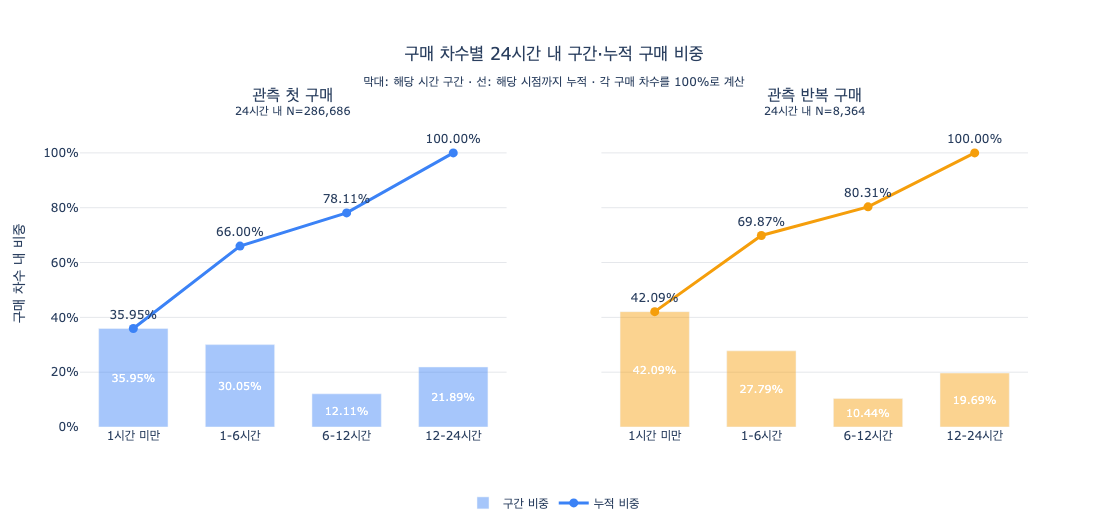

In [34]:
fig.update_layout(
    title=dict(
        text=(
            '구매 차수별 24시간 내 구간·누적 구매 비중<br>'
            '<sub>막대: 해당 시간 구간 · 선: 해당 시점까지 누적 · 각 구매 차수를 100%로 계산</sub>'
        ),
        x=0.5,
        xanchor='center',
    ),
    yaxis_range=[0, 112],
    yaxis2_range=[0, 112],
    plot_bgcolor='white',
    height=530,
    bargap=0.35,
    margin=dict(t=120, b=100),
    legend_title_text='',
    legend=dict(orientation='h', y=-0.20, x=0.5, xanchor='center', yanchor='top'),
)
fig.update_xaxes(title_text='')
fig.update_yaxes(ticksuffix='%', gridcolor='#E5E7EB')
fig.update_yaxes(title_text='구매 차수 내 비중', row=1, col=1)
fig.show()

In [35]:
delay_hour_table = delay_24h_by_order[[
    '구매차수', '기간구간', '최소_시간', '최대_시간', '평균_시간',
]]
display(delay_hour_table.round(2))

,구매차수,기간구간,최소_시간,최대_시간,평균_시간
0,관측 첫 구매,1시간 미만,0.00,1.00,0.42
1,관측 첫 구매,1-6시간,1.00,6.00,2.78
2,관측 첫 구매,6-12시간,6.00,12.00,8.98
3,관측 첫 구매,12-24시간,12.00,24.00,18.34
4,관측 반복 구매,1시간 미만,0.01,1.00,0.34
5,관측 반복 구매,1-6시간,1.00,5.99,2.84
6,관측 반복 구매,6-12시간,6.00,11.98,8.79
7,관측 반복 구매,12-24시간,12.00,23.98,18.45


In [36]:
first_6h_bins = ['1시간 미만', '1-6시간']
delay_24h_share = delay_24h_by_order.pivot(
    index='기간구간', columns='구매차수', values='24시간내_구간비중_pct'
)
overall_first6h_rate = delay_24h_overall.loc[
    delay_24h_overall['기간구간'].isin(first_6h_bins), '24시간내_구간비중_pct'
].sum()
first_1h_share = delay_24h_share.loc['1시간 미만', '관측 첫 구매']
repeat_1h_share = delay_24h_share.loc['1시간 미만', '관측 반복 구매']
first_6h_share = delay_24h_share.loc[first_6h_bins, '관측 첫 구매'].sum()
repeat_6h_share = delay_24h_share.loc[first_6h_bins, '관측 반복 구매'].sum()

In [37]:
print(f'24시간 내 구매 중 첫 6시간 비중 {overall_first6h_rate:.2f}%')
print(f'1시간 미만 비중: 관측 첫 구매 {first_1h_share:.2f}% · 관측 반복 구매 {repeat_1h_share:.2f}%')
print(f'6시간 미만 누적 비중: 관측 첫 구매 {first_6h_share:.2f}% · 관측 반복 구매 {repeat_6h_share:.2f}%')

24시간 내 구매 중 첫 6시간 비중 66.11%
1시간 미만 비중: 관측 첫 구매 35.95% · 관측 반복 구매 42.09%
6시간 미만 누적 비중: 관측 첫 구매 66.00% · 관측 반복 구매 69.87%


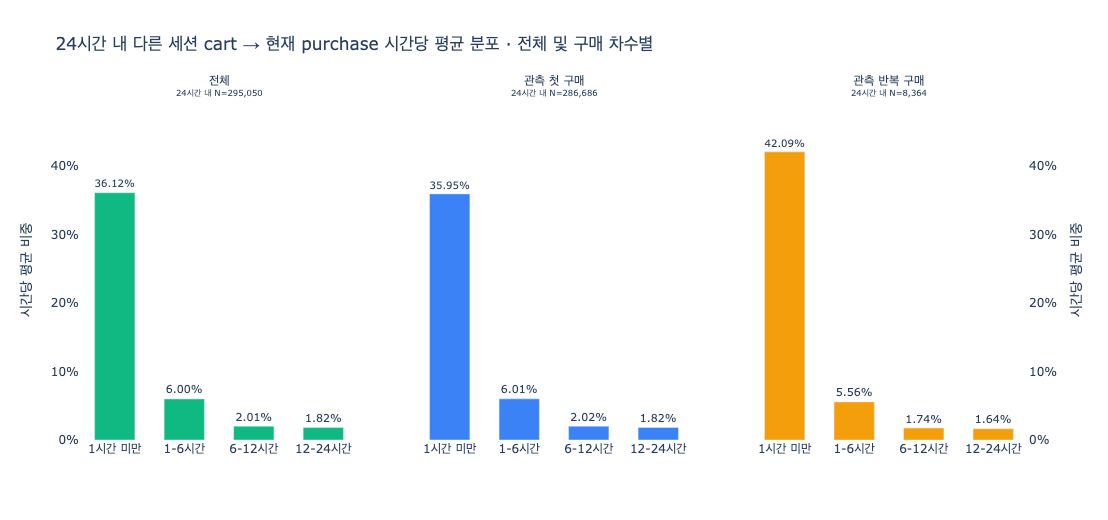

In [38]:
panel_total = delay_24h_chart.groupby('구매차수', observed=True)['구매에피소드수'].sum()
chart_max = delay_24h_chart['시간당평균_비중_pct'].max()

fig = px.bar(
    delay_24h_chart,
    x='기간구간',
    y='시간당평균_비중_pct',
    color='구매차수',
    facet_col='구매차수',
    facet_col_spacing=0.06,
    text='시간당평균_비중_pct',
    custom_data=['구매에피소드수', '24시간내_구간비중_pct', '구간시간폭_시간'],
    category_orders={'기간구간': delay_24h_bins, '구매차수': ['전체'] + purchase_order},
    color_discrete_map={
        '전체': color_map['purchase'],
        '관측 첫 구매': color_map['view'],
        '관측 반복 구매': color_map['cart'],
    },
    title='24시간 내 다른 세션 cart → 현재 purchase 시간당 평균 분포 · 전체 및 구매 차수별',
)
fig.update_traces(
    width=0.58,
    texttemplate='%{text:.2f}%',
    textposition='outside',
    textfont_size=11,
    cliponaxis=False,
    hovertemplate=(
        '%{x}<br>시간당 평균 비중 %{y:.2f}%<br>'
        '구간 전체 비중 %{customdata[1]:.2f}%<br>'
        '구간 시간 폭 %{customdata[2]:.0f}시간<br>'
        '구매 에피소드 %{customdata[0]:,.0f}<extra></extra>'
    ),
)
fig.update_yaxes(matches='y', ticksuffix='%')
fig.update_yaxes(title_text='시간당 평균 비중', showticklabels=True, row=1, col=1)
fig.update_yaxes(
    title_text='', showticklabels=False, row=1, col=2
)
fig.update_yaxes(
    title_text='시간당 평균 비중', showticklabels=True, side='right', row=1, col=3
)
fig.update_xaxes(title_text='')
fig.update_layout(
    yaxis_range=[0, chart_max * 1.18],
    yaxis2_range=[0, chart_max * 1.18],
    yaxis3_range=[0, chart_max * 1.18],
    plot_bgcolor='white',
    bargap=0.34,
    height=520,
    showlegend=False,
)
for annotation in fig.layout.annotations:
    label = annotation.text.split('=')[-1]
    annotation.text = f'{label}<br><sup>24시간 내 N={panel_total[label]:,.0f}</sup>'
fig.show()

> ### 분석 질문 3-1 관찰 결과
>
> **분석 질문 3-1.** 다른 세션 cart 연결 구매의 시간 분포는 관측 첫 구매와 관측 반복 구매에서 얼마나 다른가?
>
> **핵심 결과 — 시간 폭 보정 후 시간당 평균 비중은 1시간 미만 36.12%에서 이후 6.00% 이하로 낮아졌다**
>
> 24시간 미만 구매 에피소드 295,050개를 다시 100%로 두고, 구간 비중을 각 구간의 시간 폭으로 나눈 시간당 평균 비중을 함께 제시한다.
>
> | cart 이후 경과 시간 | 시간 폭 | 구매 에피소드 수 | 24시간 내 구간 비중 | 시간당 평균 비중 |
> |---|---:|---:|---:|---:|
> | **1시간 미만** | **1시간** | **106,573** | **36.12%** | **36.12%/시간** |
> | 1-6시간 | 5시간 | 88,485 | 29.99% | 6.00%/시간 |
> | 6-12시간 | 6시간 | 35,586 | 12.06% | 2.01%/시간 |
> | 12-24시간 | 12시간 | 64,406 | 21.83% | 1.82%/시간 |
>
> - 첫 6시간에 195,058개(66.11%)가 발생했다. 구간 시간 폭을 보정하면 시간당 평균 비중은 1시간 미만 36.12%에서 1-6시간 6.00%, 6-12시간 2.01%, 12-24시간 1.82%로 낮아졌다. 기존 구간 합계에서 보였던 12-24시간의 21.83%는 12시간을 합친 값이므로 시간당 기준의 재상승으로 해석하지 않는다.
> - 시간당 평균 비중은 `구간 비중 ÷ 구간 시간 폭`으로 계산한 단순 환산값이다. 구간 안에서 구매가 매시간 균등하게 발생했다는 뜻도 아니고, 시간당 전환율을 뜻하지도 않는다. 정확한 시간대별 밀도는 원시 시각을 1시간 단위로 다시 집계해야 한다.
> - 현재 분석은 세션 ID가 다르고 cart가 purchase보다 먼저 발생하면 `다른 세션 cart → purchase`로 집계한다. 따라서 두 세션의 활동 시간이 서로 겹쳐도 이 조건을 만족하면 1시간 미만 구간에 포함된다. 이 중 일부는 실제 재방문이 아니라 한 번의 쇼핑이 두 개의 세션 ID로 나뉘어 기록된 경우일 수 있다. 현재는 이러한 기록의 규모를 따로 계산하지 않았다.
> - 관측 첫 구매의 1시간 미만 비중은 35.95%, 관측 반복 구매는 42.09%였다. 6시간 미만 누적 비중도 각각 66.00%·69.87%로 반복 구매가 더 이른 구간에 분포했다. 다만 반복 구매의 24시간 내 표본은 8,364개로 첫 구매 286,686개보다 작다. 또한 §2와 마찬가지로 반복 구매는 직전 동일 상품 purchase 이후의 cart만 연결하므로 오래된 cart가 제외되고 purchase에 가까운 cart가 남는 구조가 같은 방향으로 작용할 수 있다. 따라서 이 차이를 구매 차수에 따른 행동 효과로 단정하지 않는다.
> - 이 결과는 최종 purchase가 확인된 에피소드만을 분모로 한 조건부 시간 분포다. 따라서 첫 6시간을 최적 CRM 발송 시점으로 해석하지 않는다. 오히려 이 구간에는 별도 개입 없이 구매할 사용자도 많이 포함될 수 있으므로, 6시간·12시간 이후 미구매자를 대상으로 한 발송 시점 실험 후보를 설계하는 근거로만 사용한다. 최종 시점은 전체 유효 cart를 분모로 한 미구매 잔존율과 A/B 테스트로 검증해야 한다.

---
## 4. 04의 낮은 카테고리 전환 신호는 세션 밖 구매까지 보아도 남는가

**비즈니스 질문.** 04에서 낮게 관찰된 우선진단 카테고리의 전환 신호는 세션을 통합한 동일 상품 구매 도달에서도 남는가?

**검토 가설 4.** 04 우선진단 카테고리는 세션 밖 구매를 포함한 30일 구매 도달에서도 그 외 카테고리보다 낮을 것이다.

**가설 수립 근거 — `04_funnel_eda.ipynb` §6.** 04 §6에서 category_id `1487580006300255120`은 view 도달 229,967개로 규모가 크면서 같은 세션·동일 상품 3단계 완주율은 0.599%에 그쳐, 전환 갭 × 트래픽 기준 기회 크기 1위로 선정됐다. 이 결과가 세션 안에서 구매를 끝내지 않은 상품 여정을 놓쳐 낮아 보인 것인지 확인하기 위해 세션 통합 30일 구매 도달을 비교한다.

**확인 기준.** category_id `1487580006300255120`과 그 외 카테고리에 동일한 사용자·상품 단위와 1·7·30일 관측 가능 조건을 적용해 구매 도달률을 비교한다. 카테고리 전반을 다시 순위화하지 않고, 기존의 낮은 전환 신호가 분석 단위를 바꾸면 해소되는지만 점검한다.

In [39]:
category_purchase_window = user_product_purchase_window.copy()
display(category_purchase_window[[
    '카테고리구분', 'view확인_사용자상품수',
    '1일_세션통합구매도달률_pct',
    '7일_세션통합구매도달률_pct',
    '30일구매판정가능_사용자상품수',
    '30일_세션통합구매_사용자상품수',
    '30일_세션통합구매도달률_pct',
]].round(3))

,카테고리구분,view확인_사용자상품수,1일_세션통합구매도달률_pct,7일_세션통합구매도달률_pct,30일구매판정가능_사용자상품수,30일_세션통합구매_사용자상품수,30일_세션통합구매도달률_pct
0,전체,6707393,4.692,5.715,5323764.0,342457.0,6.433
1,04 우선진단 카테고리,182008,1.102,1.377,146053.0,2304.0,1.578
2,그 외 카테고리,6525385,4.792,5.837,5177711.0,340153.0,6.570


In [40]:
target_paths = (
    paths.groupby(['카테고리구분', '구매경로'], as_index=False)['구매_세션상품수'].sum()
)
target_paths['카테고리내_비율_pct'] = (
    target_paths['구매_세션상품수']
    / target_paths.groupby('카테고리구분')['구매_세션상품수'].transform('sum') * 100
)
display(target_paths.round(2))

,카테고리구분,구매경로,구매_세션상품수,카테고리내_비율_pct
0,04 우선진단 카테고리,구매 전 view·cart 미확인,153,4.18
1,04 우선진단 카테고리,다른 세션 cart→현재 purchase,1410,38.54
2,04 우선진단 카테고리,다른 세션 view→현재 purchase,75,2.05
3,04 우선진단 카테고리,현재 구매 세션 cart→purchase,602,16.45
4,04 우선진단 카테고리,현재 구매 세션 view→cart→purchase,1371,37.47
5,04 우선진단 카테고리,현재 구매 세션 view→purchase,48,1.31
6,그 외 카테고리,구매 전 view·cart 미확인,87481,7.18
7,그 외 카테고리,다른 세션 cart→현재 purchase,513984,42.20
8,그 외 카테고리,다른 세션 view→현재 purchase,19052,1.56
9,그 외 카테고리,현재 구매 세션 cart→purchase,453527,37.23


In [41]:
target_category_30day_rate = float(category_purchase_window.loc[
    category_purchase_window['카테고리구분'] == '04 우선진단 카테고리',
    '30일_세션통합구매도달률_pct',
].iloc[0])
other_categories_30day_rate = float(category_purchase_window.loc[
    category_purchase_window['카테고리구분'] == '그 외 카테고리',
    '30일_세션통합구매도달률_pct',
].iloc[0])
print(
    f'30일 구매 도달률: 우선진단 {target_category_30day_rate:.3f}% · '
    f'그 외 {other_categories_30day_rate:.3f}% · '
    f'수치상 {other_categories_30day_rate / target_category_30day_rate:.2f}배'
)

30일 구매 도달률: 우선진단 1.578% · 그 외 6.570% · 수치상 4.16배


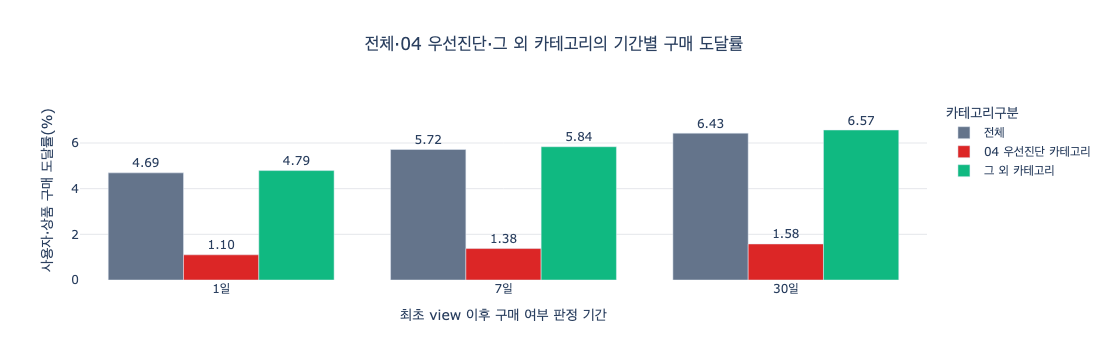

In [42]:
category_purchase_window_chart_data = category_purchase_window.melt(
    id_vars='카테고리구분',
    value_vars=[
        '1일_세션통합구매도달률_pct',
        '7일_세션통합구매도달률_pct',
        '30일_세션통합구매도달률_pct',
    ],
    var_name='관측창',
    value_name='구매도달률_pct',
)
category_purchase_window_chart_data['관측창'] = (
    category_purchase_window_chart_data['관측창'].str.extract(r'(\d+일)')
)
fig = px.bar(
    category_purchase_window_chart_data,
    x='관측창',
    y='구매도달률_pct',
    color='카테고리구분',
    barmode='group',
    text_auto='.2f',
    category_orders={
        '관측창': ['1일', '7일', '30일'],
        '카테고리구분': ['전체', '04 우선진단 카테고리', '그 외 카테고리'],
    },
    color_discrete_map={
        '전체': '#64748B',
        '04 우선진단 카테고리': '#DC2626',
        '그 외 카테고리': color_map['purchase'],
    },
    title='전체·04 우선진단·그 외 카테고리의 기간별 구매 도달률',
)
fig.update_traces(textposition='outside')
fig.update_layout(
    title_x=0.5,
    yaxis_title='사용자·상품 구매 도달률(%)',
    xaxis_title='최초 view 이후 구매 여부 판정 기간',
    yaxis_range=[0, category_purchase_window_chart_data['구매도달률_pct'].max() * 1.20],
    plot_bgcolor='white',
)
fig.update_yaxes(gridcolor='#E5E7EB')
fig.show()

> ### 검토 가설 4 관찰 결과
>
> **비즈니스 질문.** 04에서 낮게 관찰된 우선진단 카테고리의 전환 신호는 세션을 통합한 동일 상품 구매 도달에서도 남는가?
>
> **검토 가설 4.** 04 우선진단 카테고리는 세션 밖 구매를 포함한 30일 구매 도달에서도 그 외 카테고리보다 낮을 것이다.
>
> **관찰 결과 — 예상 방향과 일치.** 정식 통계 검정에 따른 가설 판정이 아니라, 관찰 데이터에서 사전에 정한 방향과 일치했는지를 확인한 결과다.
>
> **핵심 결과 — 30일 사용자·상품 구매 도달률은 우선진단 카테고리 1.578%, 그 외 카테고리 6.570%로, 그 외 카테고리가 수치상 4.16배 높았다.**
>
> | 비교 집단 | 1일 구매 도달률 | 7일 구매 도달률 | 30일 판정 가능 사용자·상품 | 30일 구매 사용자·상품 | 30일 구매 도달률 |
> |---|---:|---:|---:|---:|---:|
> | 04 우선진단 카테고리 | 1.102% | 1.377% | 146,053 | 2,304 | **1.578%** |
> | 그 외 카테고리 | 4.792% | 5.837% | 5,177,711 | 340,153 | **6.570%** |
>
> - 동일한 사용자·상품 단위와 관측 가능 조건을 적용했을 때 우선진단 카테고리는 1·7·30일 모두 그 외 카테고리보다 낮았다. 분석 단위를 바꿔도 낮은 구매 도달이 유지됐으므로, 04에서 관찰된 낮은 전환은 세션 단위 정의만으로 설명되지 않는다.
> - 구매가 확인된 세션·상품 내부에서는 우선진단 카테고리의 `현재 구매 세션 view→cart→purchase`가 1,371개(37.47%), `다른 세션 cart→현재 purchase`가 1,410개(38.54%)였다. 이는 **구매에 도달한 조합 내부의 경로 구성**이며, 최초 view가 있는 전체 사용자·상품을 분모로 한 1.578%와는 다른 지표다.
> - 따라서 해당 카테고리는 후속 진단 후보로 유지한다. 다만 `그 외 카테고리`는 나머지 카테고리를 하나로 합친 비교군이므로 카테고리 전체의 우선순위를 다시 산정한 결과가 아니다. 현재 로그만으로 낮은 구매 도달의 원인을 가격·상품 정보·UI 중 하나로 단정하지 않는다.

---
## 5. 보조 진단 — cart 없는 remove 직전에는 어떤 동일 상품 행동이 있었는가

**분석 질문 5.** 같은 세션·상품에 cart와 purchase 없이 remove만 기록된 경우, remove 직전의 가장 최근 동일 상품 상태 이벤트는 무엇인가?

**질문 수립 근거 — `04_funnel_eda.ipynb` §3.** 04 §3에서 세션 전체에 cart·purchase 없이 remove만 있는 세션 87,927개가 확인됐다. 이는 이전 세션의 장바구니 상태가 이어졌거나 관련 로그가 현재 세션에 남지 않았을 가능성을 함께 시사했다. 06에서는 분석 단위를 세션·상품으로 좁혀 동일 사용자·상품의 과거 상태 이력을 연결한다.

**확인 기준.** 분석 단위는 remove가 있지만 같은 세션·상품에 cart와 purchase가 없는 조합이다. 먼저 remove 이전 어느 시점에든 동일 상품 cart가 있었는지를 넓은 이력 신호로 확인한다. 이후 remove보다 앞선 가장 최근 cart·purchase·remove 시각을 비교해 직전 상태를 배타적으로 분류한다. 가장 최근 시각이 둘 이상 같으면 순서를 알 수 없으므로 `동일 시각 순서 주의`로 분리한다.

이 섹션은 구매 여정의 다음 단계가 아니라 04에서 남은 상태·계측 예외를 점검하는 보조 진단이다. 직전 상태가 cart여도 실제 장바구니 보유 상태를 관측한 것은 아니므로 이월을 확정하지 않는다.


In [43]:
remove_state = run(
    'pj_remove_prior_cart'
)  # 04 §3의 remove-only 예외: 전체 직전 상태와 월별 미확인을 한 번에 집계
remove_overall = remove_state.loc[remove_state['remove월'] == '전체'].copy()
remove_monthly = (
    remove_state.loc[remove_state['remove월'] != '전체']
    .sort_values('remove월')
    .reset_index(drop=True)
)
assert len(remove_overall) == 1
assert len(remove_monthly) == 5
remove_count_columns = [
    'remove_only_세션상품수', '이전cart_확인수', '이전purchase_확인수',
    '이전remove_확인수', '이전cart_미확인수', '직전상태_cart수',
    '직전상태_purchase수', '직전상태_remove수', '직전상태_미확인수',
    '직전상태_동일시각주의수',
]
assert all(
    int(remove_monthly[column].sum()) == int(remove_overall.iloc[0][column])
    for column in remove_count_columns
)


[pj_remove_prior_cart] 캐시 로드 · 6행


In [44]:
rs = remove_overall.iloc[0]
remove_total = int(rs['remove_only_세션상품수'])
prior_cart_count = int(rs['이전cart_확인수'])
latest_cart_count = int(rs['직전상태_cart수'])

remove_cart_signal = pd.DataFrame({
    'cart신호': [
        'remove 이전 cart 이력 확인',
        '직전 상태 이벤트가 cart',
        'cart 이력은 있으나 직전 상태는 cart 아님',
    ],
    '세션상품수': [
        prior_cart_count,
        latest_cart_count,
        prior_cart_count - latest_cart_count,
    ],
})
assert latest_cart_count <= prior_cart_count <= remove_total
remove_cart_signal['전체대비_비율_pct'] = (
    remove_cart_signal['세션상품수'] / remove_total * 100
)
display(remove_cart_signal.round(2))


,cart신호,세션상품수,전체대비_비율_pct
0,remove 이전 cart 이력 확인,1114627,75.74
1,직전 상태 이벤트가 cart,1070004,72.71
2,cart 이력은 있으나 직전 상태는 cart 아님,44623,3.03


In [45]:
remove_latest_state = pd.DataFrame({
    '직전상태': [
        'cart', 'purchase', 'remove',
        '이전 상태 이벤트 미확인', '동일 시각 순서 주의',
    ],
    '세션상품수': [
        int(rs['직전상태_cart수']),
        int(rs['직전상태_purchase수']),
        int(rs['직전상태_remove수']),
        int(rs['직전상태_미확인수']),
        int(rs['직전상태_동일시각주의수']),
    ],
})
assert int(remove_latest_state['세션상품수'].sum()) == remove_total
remove_latest_state['전체대비_비율_pct'] = (
    remove_latest_state['세션상품수'] / remove_total * 100
)
display(remove_latest_state.round(2))


,직전상태,세션상품수,전체대비_비율_pct
0,cart,1070004,72.71
1,purchase,8972,0.61
2,remove,41095,2.79
3,이전 상태 이벤트 미확인,350898,23.84
4,동일 시각 순서 주의,666,0.05


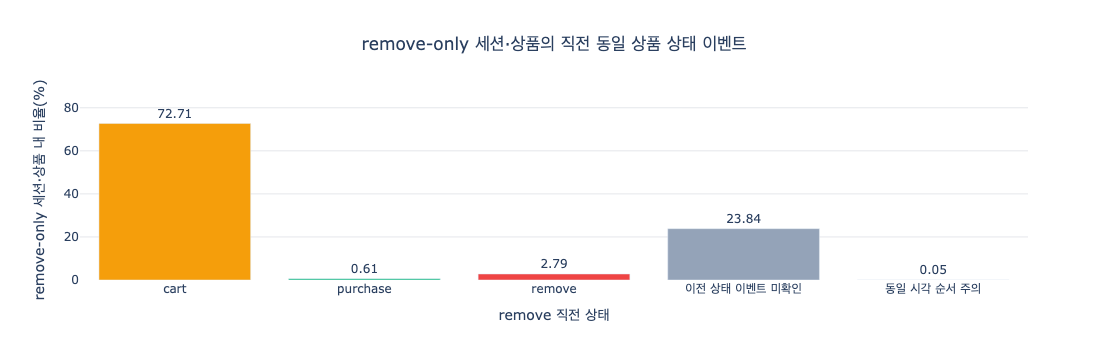

In [46]:
fig = px.bar(
    remove_latest_state,
    x='직전상태',
    y='전체대비_비율_pct',
    color='직전상태',
    text_auto='.2f',
    category_orders={
        '직전상태': [
            'cart', 'purchase', 'remove',
            '이전 상태 이벤트 미확인', '동일 시각 순서 주의',
        ],
    },
    color_discrete_map={
        'cart': color_map['cart'],
        'purchase': color_map['purchase'],
        'remove': color_map['remove'],
        '이전 상태 이벤트 미확인': '#94A3B8',
        '동일 시각 순서 주의': '#475569',
    },
    title='remove-only 세션·상품의 직전 동일 상품 상태 이벤트',
)
fig.update_traces(textposition='outside')
fig.update_layout(
    title_x=0.5,
    xaxis_title='remove 직전 상태',
    yaxis_title='remove-only 세션·상품 내 비율(%)',
    yaxis_range=[0, remove_latest_state['전체대비_비율_pct'].max() * 1.15],
    plot_bgcolor='white',
    showlegend=False,
)
fig.update_yaxes(gridcolor='#E5E7EB')
fig.show()


> ### 분석 질문 5 관찰 결과
>
> **분석 질문 5.** 같은 세션·상품에 cart와 purchase 없이 remove만 기록된 경우, remove 직전의 가장 최근 동일 상품 상태 이벤트는 무엇인가?
>
> **핵심 결과 — remove-only 세션·상품 1,471,635개 중 직전 상태 이벤트가 cart인 조합은 1,070,004개(72.71%)였다.**
>
> | remove 직전 상태 | 세션·상품 수 | 전체 대비 비율 |
> |---|---:|---:|
> | **cart** | **1,070,004** | **72.71%** |
> | purchase | 8,972 | 0.61% |
> | remove | 41,095 | 2.79% |
> | 이전 상태 이벤트 미확인 | 350,898 | 23.84% |
> | 동일 시각 순서 주의 | 666 | 0.05% |
>
> - remove 이전 어느 시점에든 cart 이력이 확인된 조합은 1,114,627개(75.74%)였지만, 가장 최근 상태까지 cart인 조합은 1,070,004개(72.71%)였다. 차이 44,623개(전체의 3.03%)에는 과거 cart 이후 더 최근의 purchase·remove 또는 동일 시각 경계가 있어, 과거 cart 존재만으로 현재 remove와 연결하기 어려운 사례가 포함된다.
> - 직전 상태가 cart인 72.71%는 세션을 넘는 장바구니 상태와 정합하는 더 강한 후보지만 이월률로 확정하지 않는다. 장바구니 상태 스냅숏, 초기화·만료, 기기 간 동기화 로그가 없어 관찰된 이벤트 사이의 실제 상태를 알 수 없기 때문이다.
> - 이전 상태 이벤트 미확인 350,898개(23.84%)에는 관측 시작 이전 행동, cart 로깅 누락, 외부 진입이나 상품 상태 변경 가능성이 함께 남는다. 동일 시각 666개(0.05%)도 보조 순번이 없어 대표 상태를 정하지 않았다.
> - 04의 87,927개는 세션 전체에 cart·purchase가 없는 세션 수이고, 본 섹션의 1,471,635개는 해당 상품에 cart·purchase가 없는 세션·상품 수다. 분석 단위와 포함 조건이 다르므로 직접 비교하거나 차감하지 않는다. 이 결과는 구매 개선 액션의 직접 근거가 아니라 상태 로그 보강 필요성을 보여주는 보조 진단으로 사용한다.


### 5.1. 이전 상태 미확인은 관측 초반에 더 높은가

**후속 검토 가설 5-1.** 이전 상태 이벤트 미확인은 관측 시작에 가까운 remove-only 조합에서 더 높게 나타날 것이다. 관측 이력이 쌓이면 동일 사용자·상품의 과거 상태를 찾을 기회가 늘어나므로, 2019-10의 미확인 비율은 이후 기간보다 높을 것으로 예상한다.

**가설 수립 근거 — 본 노트북 §5 결과.** §5에서 remove-only 세션·상품의 23.84%는 이전 cart·purchase·remove를 찾지 못했다. 이 미확인에는 관측 시작 이전 행동이 잘린 좌측 절단과 로깅 누락·외부 진입 가능성이 함께 포함된다. 관측 초반과 후반의 미확인 비율을 비교해 좌측 절단과 정합하는 시간 패턴이 있는지 확인한다.

**확인 기준.** 2019-10의 미확인 비율과 2019-11-2020-02 통합 비율을 비교하고, 개별 월 추이는 보조로 제시한다. strict한 단조 감소를 판정 조건으로 요구하지 않는다. 이 가설은 §5 결과를 본 뒤 같은 데이터에서 파생했으므로 독립적인 확증이 아니라 설명 가능성을 좁히는 탐색적 민감도 분석이다.


In [47]:
remove_monthly_show = remove_monthly[[
    'remove월', 'remove_only_세션상품수', '직전상태_미확인수',
]].copy()
remove_monthly_show['직전상태_미확인비율_pct'] = (
    remove_monthly_show['직전상태_미확인수']
    / remove_monthly_show['remove_only_세션상품수'] * 100
)
display(remove_monthly_show.round(2))


,remove월,remove_only_세션상품수,직전상태_미확인수,직전상태_미확인비율_pct
0,2019-10,276544,119436.0,43.19
1,2019-11,347410,80868.0,23.28
2,2019-12,246010,45951.0,18.68
3,2020-01,294869,54173.0,18.37
4,2020-02,306802,50470.0,16.45


In [48]:
october = remove_monthly_show.loc[
    remove_monthly_show['remove월'] == '2019-10'
].iloc[0]
later = remove_monthly_show.loc[
    remove_monthly_show['remove월'] != '2019-10'
]
later_total = int(later['remove_only_세션상품수'].sum())
later_unknown = int(later['직전상태_미확인수'].sum())

remove_cutoff_compare = pd.DataFrame({
    '비교기간': ['2019-10', '2019-11-2020-02 통합'],
    'remove_only_세션상품수': [
        int(october['remove_only_세션상품수']), later_total,
    ],
    '직전상태_미확인수': [
        int(october['직전상태_미확인수']), later_unknown,
    ],
})
remove_cutoff_compare['직전상태_미확인비율_pct'] = (
    remove_cutoff_compare['직전상태_미확인수']
    / remove_cutoff_compare['remove_only_세션상품수'] * 100
)
remove_cutoff_gap_pctp = (
    remove_cutoff_compare.loc[0, '직전상태_미확인비율_pct']
    - remove_cutoff_compare.loc[1, '직전상태_미확인비율_pct']
)
display(remove_cutoff_compare.round(2))
print(f'2019-10 미확인 비율 격차: 이후 통합 대비 {remove_cutoff_gap_pctp:.2f}%p 높음')


,비교기간,remove_only_세션상품수,직전상태_미확인수,직전상태_미확인비율_pct
0,2019-10,276544,119436,43.19
1,2019-11-2020-02 통합,1195091,231462,19.37


2019-10 미확인 비율 격차: 이후 통합 대비 23.82%p 높음


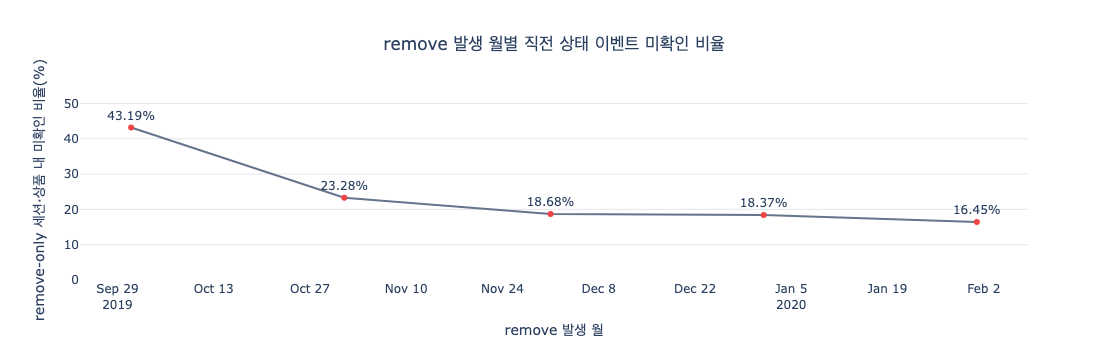

In [49]:
fig = px.line(
    remove_monthly_show,
    x='remove월',
    y='직전상태_미확인비율_pct',
    markers=True,
    text='직전상태_미확인비율_pct',
    title='remove 발생 월별 직전 상태 이벤트 미확인 비율',
)
fig.update_traces(
    line_color='#64748B',
    marker_color='#EF4444',
    texttemplate='%{text:.2f}%',
    textposition='top center',
)
fig.update_layout(
    title_x=0.5,
    xaxis_title='remove 발생 월',
    yaxis_title='remove-only 세션·상품 내 미확인 비율(%)',
    yaxis_range=[0, remove_monthly_show['직전상태_미확인비율_pct'].max() * 1.18],
    plot_bgcolor='white',
)
fig.update_yaxes(gridcolor='#E5E7EB')
fig.show()


> ### 후속 검토 가설 5-1 관찰 결과
>
> **후속 검토 가설 5-1.** 이전 상태 이벤트 미확인은 관측 시작에 가까운 remove-only 조합에서 더 높게 나타날 것이다.
>
> **핵심 결과 — 이전 상태 미확인 비율은 2019-10 43.19%, 2019-11-2020-02 통합 19.37%로 관측 초반이 23.82%p 높았다.**
>
> | remove 발생 월 | remove-only 세션·상품 | 이전 상태 미확인 | 미확인 비율 |
> |---|---:|---:|---:|
> | **2019-10** | **276,544** | **119,436** | **43.19%** |
> | 2019-11 | 347,410 | 80,868 | 23.28% |
> | 2019-12 | 246,010 | 45,951 | 18.68% |
> | 2020-01 | 294,869 | 54,173 | 18.37% |
> | 2020-02 | 306,802 | 50,470 | 16.45% |
>
> - 2019-10의 미확인 비율은 이후 4개월 통합 19.37%보다 23.82%p 높았고, 개별 월도 43.19%에서 16.45%까지 낮아졌다. 관측 이력이 짧은 초반에 미확인이 집중된 방향은 좌측 절단과 정합한다.
> - 따라서 전체 미확인 23.84% 중 일부에는 관측 시작 이전 동일 상품 행동을 볼 수 없는 영향이 포함됐을 가능성이 크다. 다만 월별 사용자·상품 구성이나 로깅 환경 변화도 같은 패턴을 만들 수 있어 좌측 절단의 기여분을 수치로 확정하지 않는다.
> - 마지막 달인 2020-02에도 50,470개(16.45%)가 미확인으로 남았다. 좌측 절단만으로 모든 미확인을 설명할 수 없으며, cart 로깅 누락·외부 진입·관측되지 않은 상태 변경 가능성은 계속 남는다.
> - 이 가설은 §5 결과를 본 뒤 같은 관측 데이터에서 파생해 확인한 탐색 가설이다. 독립 표본에서 재현한 결과가 아니므로 `입증`이나 인과 판정으로 표현하지 않고, 미확인의 설명 범위를 좁힌 민감도 결과로 사용한다.


---
## 6. 문제 해결 결과와 후속 실험 설계

### 6.1. 실험 전에 알아야 할 기본 숫자

**설계 질문.** 상품을 장바구니에 담고 24시간이 지나도 사지 않은 사용자에게 알림을 보내려고 한다. 알림을 보내지 않아도 이들 중 몇 %가 알림 기준 시점 후 7일 이내에 같은 상품을 구매하며, 알림 효과를 비교하려면 사용자 몇 명을 얼마나 오래 모아야 하는가?

#### 누구를 실험 후보로 세는가?

1. 사용자마다 관측 기간에 처음 확인된 cart 한 건만 고른다.
2. 그 cart 이후 24시간 안에 같은 상품을 구매하지 않았으면 `cart+24시간`에 실험 후보가 된다.
3. 그 시점부터 이후 7일 전체의 데이터가 존재해, 7일 이내 구매 여부를 판단할 수 있는 사용자만 계산한다.
4. 한 사용자가 같은 시각에 여러 상품을 처음 담았다면, 결과를 항상 똑같이 재현하기 위해 `product_id`가 작은 상품 한 건을 대표로 고른다.

```text
cart 발생 ── 24시간 동안 같은 상품 미구매 ── 실험 후보 시점 ── 이후 7일 구매 확인
                                            └─ 실제 실험에서는 이때 알림 발송
```

#### 이 섹션에서 사용하는 지표

| 지표 | 계산 방법 | 설명 |
|---|---|---|
| 실험 후보 시점 (`실험적격일`) | 최초 cart 시각 + 24시간 | 실제 실험에서 알림을 보낼 시각 |
| 기준 시점 후 7일 이내 구매 판정 대상 (`실험적격_사용자수`) | 실험 후보 시점부터 이후 7일 전체의 데이터가 존재하는 사용자 | 7일 이내에 구매했는지와 구매하지 않았는지를 모두 판단할 수 있는 사용자 |
| 기준 시점 후 7일 이내 동일 상품 구매 사용자 (`기준점후_7일_동일상품구매_사용자수`) | 위 판정 대상 중 실험 후보 시점 후 7일 이내에 같은 상품을 구매한 사용자 | 7일 구매율의 분자 |
| 기준 시점 후 7일 이내 동일 상품 구매율 | 7일 이내 동일 상품 구매 사용자 ÷ 7일 이내 구매 판정 대상 × 100 | 알림이 없어도 기준 시점 후 7일 이내에 구매한 비율 |
| 기준 시점 후 30일 이내 구매 판정 대상 (`기준점후_30일_판정가능_사용자수`) | 실험 후보 시점부터 이후 30일 전체의 데이터가 존재하는 사용자 | 30일 이내 구매 여부를 판단할 수 있는 사용자 |
| 기준 시점 후 30일 이내 동일 상품 구매율 (`기준점후_30일_동일상품구매_사용자수` ÷ 판정 대상) | 30일 이내 동일 상품 구매 사용자 ÷ 30일 이내 구매 판정 대상 × 100 | 장기 구매 여부를 보기 위한 별도 지표 |
| 하루 실험 후보 수 | 실험 후보가 된 사용자 수의 일별 평균·중앙값 | 필요한 전체 표본을 며칠 동안 모아야 하는지 계산할 때 사용 |
| MDE | 실험 설계에서 구별하려는 최소 구매율 차이 | 차이가 작을수록 더 많은 사용자가 필요 |

두 지표는 정확히 7일째·30일째 발생한 구매가 아니라, 각각 기준 시점 후 **7일 이내·30일 이내** 발생한 구매를 센다. 30일 이내 구매 판정 대상은 7일 이내 구매 판정 대상의 부분집합이지만, 7일만 관측할 수 있고 30일은 관측할 수 없는 사용자가 있어 두 구매율의 분모는 다르다.

#### 왜 §3의 57.25%와 다른 숫자인가?

§3의 57.25%는 **결국 구매한 사람만** 모아 놓고 그중 cart 후 24시간 이내에 산 비중을 계산한 값이다. 여기서는 반대로 **cart 후 24시간 동안 사지 않은 실험 후보 전체**를 분모로 두고, 기준 시점 후 7일 이내에 자연스럽게 구매하는 비율을 계산한다. 따라서 이번 값이 알림을 보내지 않은 대조군의 예상 구매율, 즉 실험 기준선에 더 가깝다.

현재 데이터에는 실시간 장바구니 상태와 메시지 수신 동의가 없다. 따라서 실제 발송 직전에는 이미 장바구니에서 뺐는지, 상품이 품절·판매 중지됐는지, 메시지를 받을 수 있는 사용자인지를 추가로 확인해야 한다.

In [50]:
experiment_baseline_daily = run(
    'pj_experiment_baseline'
)  # cart+24시간 CRM 실험: 사용자별 최초 적격 cart의 일별 7일 구매 기준선·사전 세그먼트
experiment_baseline_daily['실험적격일'] = pd.to_datetime(
    experiment_baseline_daily['실험적격일']
)
experiment_baseline_numeric_cols = [
    col for col in experiment_baseline_daily.columns
    if col not in ('실험적격일', '구매차수_사전세그먼트')
]
experiment_baseline_daily[experiment_baseline_numeric_cols] = (
    experiment_baseline_daily[experiment_baseline_numeric_cols].fillna(0)
)
display(experiment_baseline_daily.head())

[pj_experiment_baseline] 캐시 로드 · 158행


,실험적격일,구매차수_사전세그먼트,실험적격_사용자수,기준점후_7일_동일상품구매_사용자수,기준점후_30일_판정가능_사용자수,기준점후_30일_동일상품구매_사용자수,다중purchase_기준시각경계주의_사용자수
0,2019-10-02,관측 첫 구매 후보,6623,186.0,6623.0,276.0,0.0
1,2019-10-03,관측 반복 구매 후보,1,0.0,1.0,0.0,0.0
2,2019-10-03,관측 첫 구매 후보,20699,154.0,20699.0,239.0,0.0
3,2019-10-04,관측 첫 구매 후보,3148,124.0,3148.0,192.0,0.0
4,2019-10-05,관측 첫 구매 후보,2339,105.0,2339.0,170.0,0.0


In [51]:
eligible_user_count = int(experiment_baseline_daily['실험적격_사용자수'].sum())
purchase_7day_user_count = int(
    experiment_baseline_daily['기준점후_7일_동일상품구매_사용자수'].sum()
)
purchase_30day_eligible_count = int(
    experiment_baseline_daily['기준점후_30일_판정가능_사용자수'].sum()
)
purchase_30day_user_count = int(
    experiment_baseline_daily['기준점후_30일_동일상품구매_사용자수'].sum()
)
boundary_user_count = int(
    experiment_baseline_daily['다중purchase_기준시각경계주의_사용자수'].sum()
)
assert 0 <= purchase_7day_user_count <= eligible_user_count
assert 0 <= purchase_30day_user_count <= purchase_30day_eligible_count <= eligible_user_count

baseline_7day_rate = purchase_7day_user_count / eligible_user_count
baseline_30day_rate = purchase_30day_user_count / purchase_30day_eligible_count
experiment_baseline_summary = pd.DataFrame({
    '지표': ['기준점 후 7일 동일 상품 구매', '기준점 후 30일 동일 상품 구매'],
    '판정가능_사용자수': [eligible_user_count, purchase_30day_eligible_count],
    '구매_사용자수': [purchase_7day_user_count, purchase_30day_user_count],
    '구매율_pct': [baseline_7day_rate * 100, baseline_30day_rate * 100],
})
display(experiment_baseline_summary.round(3))
print(
    f'다중 purchase 기준시각 경계 주의 {boundary_user_count:,}명 '    f'({boundary_user_count / eligible_user_count * 100:.3f}%)'
)

,지표,판정가능_사용자수,구매_사용자수,구매율_pct
0,기준점 후 7일 동일 상품 구매,320360,8123,2.536
1,기준점 후 30일 동일 상품 구매,279520,10750,3.846


다중 purchase 기준시각 경계 주의 0명 (0.000%)


In [52]:
experiment_segment_summary = (
    experiment_baseline_daily
    .groupby('구매차수_사전세그먼트', as_index=False)[[
        '실험적격_사용자수',
        '기준점후_7일_동일상품구매_사용자수',
    ]]
    .sum()
)
experiment_segment_summary['기준점후_7일_동일상품구매율_pct'] = (
    experiment_segment_summary['기준점후_7일_동일상품구매_사용자수']
    / experiment_segment_summary['실험적격_사용자수'] * 100
)
display(experiment_segment_summary.round(3))

,구매차수_사전세그먼트,실험적격_사용자수,기준점후_7일_동일상품구매_사용자수,기준점후_7일_동일상품구매율_pct
0,관측 반복 구매 후보,16,1.0,6.250
1,관측 첫 구매 후보,320344,8122.0,2.535


In [53]:
daily_eligible_users = (
    experiment_baseline_daily
    .groupby('실험적격일')['실험적격_사용자수']
    .sum()
)
full_eligible_dates = pd.date_range(
    daily_eligible_users.index.min(),
    daily_eligible_users.index.max(),
    freq='D',
)
daily_eligible_users = daily_eligible_users.reindex(full_eligible_dates, fill_value=0)
average_daily_eligible_users = float(daily_eligible_users.mean())
median_daily_eligible_users = float(daily_eligible_users.median())

def two_proportion_sample_size(p0, relative_lift, alpha=0.05, power=0.80):
    p1 = p0 * (1 + relative_lift)
    pooled = (p0 + p1) / 2
    z_alpha = NormalDist().inv_cdf(1 - alpha / 2)
    z_power = NormalDist().inv_cdf(power)
    numerator = (
        z_alpha * math.sqrt(2 * pooled * (1 - pooled))
        + z_power * math.sqrt(p0 * (1 - p0) + p1 * (1 - p1))
    ) ** 2
    return p1, math.ceil(numerator / (p1 - p0) ** 2)

sample_size_rows = []
for relative_lift in (0.05, 0.10):
    target_rate, users_per_group = two_proportion_sample_size(
        baseline_7day_rate, relative_lift
    )
    total_users = users_per_group * 2
    recruitment_days = math.ceil(total_users / average_daily_eligible_users)
    sample_size_rows.append({
        '상대_MDE': f'+{relative_lift * 100:.0f}%',
        '기준구매율_pct': baseline_7day_rate * 100,
        '처리군_목표구매율_pct': target_rate * 100,
        '절대_MDE_pctp': (target_rate - baseline_7day_rate) * 100,
        '군별_필요사용자수': users_per_group,
        '전체_필요사용자수': total_users,
        '예상_모집일수': recruitment_days,
        '7일추적포함_최소일수': recruitment_days + 7,
        '과거관측기간내_모집가능여부': (
            '가능' if recruitment_days + 7 <= len(daily_eligible_users) else '어려움'
        ),
    })

experiment_sample_size = pd.DataFrame(sample_size_rows)
display(experiment_sample_size.round(3))
print(
    f'과거 적격 사용자 유입: 일평균 {average_daily_eligible_users:,.1f}명 · '
    f'일중앙값 {median_daily_eligible_users:,.1f}명 · '
    f'관측 {len(daily_eligible_users):,}일'
)

,상대_MDE,기준구매율_pct,처리군_목표구매율_pct,절대_MDE_pctp,군별_필요사용자수,전체_필요사용자수,예상_모집일수,7일추적포함_최소일수,과거관측기간내_모집가능여부
0,+5%,2.536,2.662,0.127,247233,494466,223,230,어려움
1,+10%,2.536,2.789,0.254,63274,126548,57,64,가능


과거 적격 사용자 유입: 일평균 2,224.7명 · 일중앙값 1,830.5명 · 관측 144일


> ### §6.1 결과 — 알림 기준 시점 후 7일 이내 자연 구매율은 2.536%
>
> **기준 시점 후 7일 이내 구매 판정 대상 320,360명 중 8,123명이 알림 없이도 같은 상품을 구매했다. 이 2.536%를 대조군의 예상 구매율로 두고 필요한 실험 규모를 계산했다.**
>
> | 지표 | 결과 | 의미 |
> |---|---:|---|
> | 기준 시점 후 7일 이내 구매 판정 대상 (`실험적격_사용자수`) | 320,360명 | 7일 구매율의 분모 |
> | 기준 시점 후 7일 이내 동일 상품 구매 (`기준점후_7일_동일상품구매_사용자수`) | 8,123명 (2.536%) | 알림 없이 발생한 자연 구매 |
> | 기준 시점 후 30일 이내 구매 판정 대상 (`기준점후_30일_판정가능_사용자수`) | 279,520명 | 30일 구매율의 별도 분모 |
> | 기준 시점 후 30일 이내 동일 상품 구매 (`기준점후_30일_동일상품구매_사용자수`) | 10,750명 (3.846%) | 구매 시점 이동을 확인할 장기 참고값 |
> | 하루에 들어오는 실험 후보 | 평균 2,224.7명 · 중앙값 1,830.5명 | 필요한 사용자를 모으는 기간 계산에 사용 |
>
> 7일 이내 구매 판정 대상과 30일 이내 구매 판정 대상의 관계는 다음과 같다.
>
> ```text
> 기준 시점 후 7일 이내 구매 판정 대상 320,360명
> ├─ 30일 이내 구매도 판정 가능         279,520명
> └─ 7일 이내 구매만 판정 가능           40,840명
> ```
>
> 30일 이내 구매 10,750명에는 30일 이내 구매 판정 대상 중 첫 7일 이내에 구매한 사람도 포함된다. 그러나 7일 이내 구매 8,123명은 더 넓은 320,360명을 대상으로 계산했으므로 두 구매자 수나 비율을 직접 빼서 ‘8~30일 사이 추가 구매’로 계산하지 않는다.
>
> #### MDE는 무엇인가?
>
> MDE는 **현재 트래픽으로 실험에서 구분해 내려는 최소 차이**다. 여기서 상대 10% 개선은 구매율이 10%p 오른다는 뜻이 아니다. 기준 구매율 2.536%에 10%를 곱해 **2.789%로 오르는 것(+0.254%p)** 을 뜻한다.
>
> | 상대 개선폭 (`상대_MDE`) | 대조군 예상 구매율 (`기준구매율_pct`) | 처리군 목표 구매율 (`처리군_목표구매율_pct`) | 필요한 전체 사용자 (`전체_필요사용자수`) | 예상 기간 | 판단 |
> |---|---:|---:|---:|---:|---|
> | 상대 5% 개선 | 2.536% | 2.662% | 494,466명 | 모집 223일 + 결과 확인 7일 = 최소 230일 | 현재 데이터 기간으로는 어려움 |
> | 상대 10% 개선 | 2.536% | 2.789% | 126,548명 | 모집 57일 + 결과 확인 7일 = 최소 64일 | 1차 실험 후보 |
>
> 실제 운영에서는 메시지 수신 동의가 없거나 장바구니에서 상품을 제거했거나 상품이 품절된 사용자를 제외해야 한다. 그러면 하루 실험 후보가 과거 평균 2,224.7명보다 줄어 실제 실험 기간은 위 계산보다 길어질 수 있다.
>
> 사용자별 최초 cart만 고른 이번 기준선에서 과거 동일 상품 구매가 있던 반복 구매 후보는 16명뿐이었다. 따라서 1차 실험에서 첫 구매·반복 구매를 따로 비교하기에는 부족하며, 반복 구매 CRM은 별도 모집 기준이 필요하다. 표본 수는 유의수준 5%·검정력 80%의 근사 계산이며 트래픽 변동과 실험 이탈은 반영하지 않았다.

> ### 검토 가설·분석 질문 관찰 결과
>
> **한 줄 결론 — 최초 view 이후 30일 이내에 관찰된 동일 상품 구매 중 69.53%는 같은 세션에서 `view → cart → purchase`를 마친 사용자·상품(`동일세션_view_cart_purchase완주_사용자상품수`)이 아니었다. 구매가 발생한 세션·상품을 경로별로 나누면 이전 구매 이후 다른 세션에서 cart가 확인된 구매(`다른 세션 cart→현재 purchase`)가 42.19%로 가장 컸고, 그중 57.25%는 cart 후 24시간 이내에 구매했다. 이 결과를 바탕으로 cart+24시간 알림을 후속 실험 후보로 정했다.**
>
> | 구분 | 관찰 결과 | 의사결정 연결 |
> |---|---|---|
> | 가설 1 | 최초 view 시점 후 1일·7일·30일 전체의 데이터가 각각 존재하는 동일 사용자·상품을 기간별 분모로 삼았다. 같은 세션에서 동일 상품 `view → cart → purchase`를 마친 비율(`동일세션_view_cart_purchase완주율_pct`)은 1일 1.815%·7일 1.881%·30일 1.960%, 여러 세션을 합쳐 같은 상품 구매만 확인한 비율(`세션통합_동일상품구매도달률_pct`)은 4.692%·5.715%·6.433%였다. | 30일 이내에 관찰된 동일 상품 구매 중 69.53%는 같은 세션 3단계 완주 밖에 있었다. 단, 1일·7일·30일마다 구매 판정 대상이 달라 기간별 증가율로 비교하지 않는다. |
> | 가설 2 | 구매가 있는 세션·상품을 서로 겹치지 않는 여섯 경로로 분류했다. 직전 동일 상품 구매 이후 다른 세션의 cart가 현재 구매보다 먼저 확인된 경로가 42.19%로 가장 컸고, 현재 구매 세션 안의 cart 연결 경로보다 5.01%p 높았다. | 오래된 cart를 이전 구매에서 끊은 뒤에도 다른 세션 cart 연결이 가장 큰 구매 경로로 남았다. |
> | 분석 질문 2-1 | 데이터 기간 안에서 처음 관찰된 동일 상품 구매(`관측 첫 구매`)는 9.20%, 이전 동일 상품 구매가 이미 관찰된 구매(`관측 반복 구매`)는 25.93%에서 이번 구매 전에 cart를 찾지 못했다. 반복 구매 중 view와 cart를 모두 찾지 못한 경로(`구매 전 view·cart 미확인`)는 22.15%였다. | 반복 구매에서 cart 미확인이 더 많이 관찰됐지만, 이전 구매 이후만 검색해 행동을 찾는 기간이 짧고 로그 누락도 가능하므로 실제 cart를 건너뛰었다고 확정하지 않는다. |
> | 가설 3 | 이전 구매 이후 다른 세션 cart가 확인되고 결국 구매까지 이어진 515,394개 구매 에피소드만 대상으로 실제 cart→purchase 시간을 계산했다. 57.25%가 24시간 미만이었다. | 이미 구매에 성공한 사례 안의 시간 분포이므로 전체 cart의 구매 확률이나 최적 발송 시각을 뜻하지 않는다. 24시간은 실험할 후보 시점으로만 사용한다. |
> | 분석 질문 3-1 | 위 515,394개 중 관측 첫 구매와 반복 구매를 나눴을 때 24시간 미만 비중 차이는 2.98%p, 7일 미만 누적 비중 차이는 0.76%p였다. | 두 집단의 시간 분포가 비슷하게 관찰됐지만 표본 크기와 행동 탐색 기간이 달라 완전히 같다고 결론 내리지 않는다. |
> | 가설 4 | 최초 view 시점 후 30일 전체의 데이터가 존재해 30일 이내 구매를 판정할 수 있는 사용자·상품에서, 04 우선진단 카테고리의 동일 상품 구매율은 1.578%, 그 외 카테고리를 합친 비교군은 6.570%였다. | 세션을 합쳐도 낮은 구매 신호가 남았다. 다만 ‘그 외’는 여러 카테고리를 합친 값이므로 전체 카테고리 순위를 다시 계산한 결과는 아니다. |
> | 분석 질문 5 | 현재 세션·상품에는 cart와 purchase가 없고 remove만 있는 경우(`remove_only_세션상품수`)를 조사했다. 75.74%는 과거에 같은 상품 cart가 한 번 이상 있었고(`이전cart_확인수`), 72.71%는 remove보다 앞선 cart·purchase·remove 중 가장 최근 이벤트가 cart였다(`직전상태_cart수`). | 장바구니가 세션을 넘어 남아 있었을 가능성과 맞지만, 실제 장바구니 상태를 기록한 값이 아니므로 이월을 확정하지 않는다. |
> | 후속 검토 가설 5-1 | remove 이전에 같은 상품의 cart·purchase·remove를 하나도 찾지 못한 비율은 2019-10 43.19%에서 2020-02 16.45%까지 매월 낮아졌다. 2019-11~2020-02 통합값은 19.37%였다. | 데이터 시작 전 행동을 볼 수 없는 관측 초기의 한계와 맞는 패턴이다. 다만 감소분 전체가 관측 시작 이전 데이터 누락 때문이라고 확정하지 않는다. |
>
> ### 핵심 발견
>
> - **같은 세션의 3단계만 보면 동일 상품 구매의 다수를 놓친다.** 최초 view 시점 후 30일 전체의 데이터가 존재하는 동일 사용자·상품 5,323,764개를 공통 분모로 두면, 같은 세션에서 동일 상품 `view → cart → purchase`를 마친 조합(`동일세션_view_cart_purchase완주_사용자상품수`)은 104,363개(1.960%), 여러 세션을 합쳐 cart 여부와 관계없이 30일 이내 같은 상품 구매가 확인된 조합(`세션통합_동일상품구매_사용자상품수`)은 342,457개(6.433%)였다. 차이 238,094개(`동일세션_3단계밖_구매_사용자상품수`)는 관찰된 구매 342,457개의 69.53%다. 이 차이에는 세션 간 구매뿐 아니라 cart를 거치지 않았거나 순서를 확인할 수 없는 구매도 포함된다.
> - **가장 많이 관찰된 구매 경로는 다른 세션에서 담고 현재 세션에서 구매한 경로(`다른 세션 cart→현재 purchase`)였다.** 구매가 있는 세션·상품을 한 경로에만 들어가도록 분류했을 때 42.19%는 직전 동일 상품 구매 이후의 다른 세션 cart가 현재 purchase보다 먼저 있었다. 즉 이전 구매에 속할 오래된 cart를 제외해도 다른 세션에서 담고 현재 세션에서 산 경로가 가장 많았다.
> - **반복 구매는 구매 전 cart를 찾지 못한 비중이 더 컸다.** 데이터 안의 첫 구매는 9.20%, 반복 구매는 25.93%에서 직전 구매 이후 현재 구매 전까지 cart가 확인되지 않았다. 하지만 반복 구매는 행동을 찾는 기간이 더 짧고 로그 누락도 가능하므로 ‘장바구니를 건너뛴 재주문’으로 확정하지 않는다.
> - **다른 세션 cart 뒤 구매에 성공한 사례는 초반에 집중됐다.** 이 경로로 실제 구매까지 이어진 515,394개 중 57.25%는 24시간 이내, 84.57%는 7일 이내에 구매했다. 전체 cart 사용자가 아니라 이미 구매에 성공한 사례만 본 값이므로 구매 확률이나 알림 효과를 뜻하지 않는다.
> - **실험 대조군의 예상 7일 이내 구매율은 2.536%다.** 사용자별 최초 cart 후 24시간 동안 같은 상품을 사지 않았고 기준 시점 이후 7일 전체의 데이터가 존재하는 320,360명 중 8,123명이 알림 없이도 7일 이내 구매했다. 상대 10% 차이를 구별하려면 최소 약 64일, 상대 5% 차이는 약 230일이 필요하다.
> - **04 우선진단 카테고리의 낮은 구매 신호는 세션을 합쳐도 남았다.** 최초 view 후 30일 동일 상품 구매율은 우선진단 카테고리 1.578%, 나머지 카테고리를 합친 비교군 6.570%였다.
> - **remove-only 기록의 다수는 이전 cart와 연결됐다.** 현재 세션·상품에 cart·purchase 없이 remove만 있는 경우 중 75.74%는 과거 같은 상품 cart가 있었고, 72.71%는 remove 전 가장 최근 상태 이벤트가 cart였다. 과거 상태를 찾지 못한 비율이 관측 첫 달 43.19%에서 마지막 달 16.45%로 낮아졌지만, 실제 장바구니 이월과 데이터 시작 이전 행동 누락의 기여분은 구분할 수 없다.

> ### 개선안 — 24시간 장바구니 알림 A/B 테스트
>
> **확인할 것 — 알림을 보내지 않아도 발생하는 2.536%의 자연 구매보다, 24시간 장바구니 알림을 보냈을 때 같은 상품 구매가 실제로 더 늘어나는가?**
>
> 24시간은 구매에 성공한 다른 세션 cart 경로가 초반에 집중된 점을 고려해 즉시 개입을 피하고, cart 발생 시각과 같은 시각대에 일관되게 발송할 수 있어 1차 후보로 선택했다. 다만 성공 구매 사례만 본 관찰을 바탕으로 한 운영 후보일 뿐, 전체 cart의 자연 구매가 24시간 안에 끝나거나 24시간이 최적이라는 뜻은 아니다.
>
> | 설계 항목 | 정의 |
> |---|---|
> | 실험 대상 | 사용자별 첫 cart 이후 24시간 동안 같은 상품을 사지 않은 사용자 |
> | 배정 단위 | 사용자(`user_id`) 단위로 1:1 무작위 배정 |
> | 처리군 | cart+24시간에 해당 상품 알림 1회 발송 |
> | 대조군 | 알림을 보내지 않음 |
> | 쿠폰 | 1차 실험에서는 사용하지 않음. 알림 효과와 할인 효과가 섞이는 것을 방지 |
> | 예상 기준선 | 대조군 약 2.536% |
> | 현실적인 규모안 | 상대 10% 차이를 확인하는 데 전체 126,548명·최소 약 64일 |
>
> #### 실험 평가 지표
>
> | 구분 | 지표 | 계산 방법 | 판단에 사용하는 이유 |
> |---|---|---|---|
> | **주지표** | 기준 시점 후 7일 이내 동일 상품 구매율 (`기준점후_7일_동일상품구매율`) | 무작위 배정 후 7일 전체를 관측한 사용자 중 같은 상품을 7일 이내 구매한 사용자 비율 | 알림이 목표 상품 구매를 늘렸는지 판단하는 가장 중요한 지표 |
> | **보조지표** | 기준 시점 후 1일 이내 동일 상품 구매율 (`기준점후_1일_동일상품구매율`) | 배정 후 1일 이내 같은 상품을 구매한 사용자 비율 | 알림 직후의 단기 반응 확인 |
> | **보조지표** | 기준 시점 후 30일 이내 동일 상품 구매율 (`기준점후_30일_동일상품구매율`) | 배정 후 30일 이내 같은 상품을 구매한 사용자 비율 | 7일 차이가 장기에도 남는지, 구매 시점만 앞당겼는지 확인 |
> | **보조지표** | 사용자당 해당 상품 매출 (`동일상품_사용자당_revenue`) | 각 집단의 해당 상품 매출 합계 ÷ 배정 사용자 수 | 구매율 상승이 실제 해당 상품 매출과도 연결되는지 확인 |
> | **운영 참고지표** | 메시지 클릭률 (`메시지_클릭률`) | 처리군에서 메시지를 클릭한 사용자 ÷ 메시지가 정상 발송된 사용자 | 메시지가 실제로 열람됐는지 확인하며, 미발송 대조군과 효과를 직접 비교하는 지표는 아님 |
> | **가드레일 지표** | 사용자당 전체 상품 구매 건수 (`전체상품_사용자당_구매건수`) | 각 집단의 모든 상품 구매 건수 ÷ 배정 사용자 수 | 알림 상품 구매가 늘면서 전체 구매가 줄어드는지 확인 |
> | **가드레일 지표** | 사용자당 전체 상품 매출 (`전체상품_사용자당_revenue`) | 각 집단의 모든 상품 매출 합계 ÷ 배정 사용자 수 | 다른 상품 구매를 알림 상품으로 옮기기만 했는지 확인 |
> | **가드레일 지표** | 수신 거부율·신고율 (`수신거부율`, `신고율`) | 수신 거부·신고 사용자 ÷ 메시지가 정상 발송된 사용자 | 알림으로 인한 고객 불편 확인 |
> | **가드레일 지표** | 반품률·취소율 (`반품률`, `취소율`) | 구매 후 반품·취소 건수 ÷ 구매 건수 | 단기 구매 증가가 저품질 주문을 늘렸는지 확인 |
>
> 주지표와 구매·매출 가드레일은 사용자를 처음 배정한 집단 그대로 비교한다. 예를 들어 처리군으로 배정됐지만 메시지를 클릭하지 않은 사용자도 처리군 분모에서 빼지 않는다. 현재 데이터에는 메시지 발송·클릭·수신 거부·신고·확정 반품·취소 컬럼이 없으므로, 괄호 안 이름은 실제 실험 로그에 추가할 권장 지표명이다.
>
> #### 결과는 세 단계로 판단한다
>
> 1. **7일 이내 구매가 늘었는가?** 처리군 구매율에서 대조군 구매율을 뺀 차이와 신뢰구간을 확인한다. 신뢰구간은 표본 오차를 고려했을 때 실제 차이가 있을 법한 범위다. 실험 시작 전에는 ‘이 정도는 올라야 사업적으로 의미가 있다’는 최소 개선폭을 별도로 합의한다. MDE는 필요한 표본을 계산하는 값이지 자동 성공 기준이 아니다.
> 2. **새 구매인가, 구매 시점만 앞당긴 것인가?** 실제 실험에서는 처음 배정한 동일 사용자를 30일까지 관찰하고, 그 사용자들의 7일 효과와 30일 효과를 비교한다. 7일에는 차이가 있지만 30일에는 사전에 정한 허용 범위 안으로 줄어들면, 새 구매를 만들기보다 구매 시점만 앞당겼을 가능성을 검토한다. 현재 과거 데이터는 끝부분 사용자를 30일까지 볼 수 없어 7일 기준선(320,360명)과 30일 기준선(279,520명)의 대상이 다르므로 두 비율을 직접 비교하지 않는다.
> 3. **다른 지표를 해치지 않았는가?** 수신 거부·신고·반품·취소뿐 아니라 사용자당 전체 상품 구매 건수와 전체 상품 매출도 확인한다. 알림 상품 구매만 늘고 전체 매출이 줄었다면 다른 상품 구매를 옮긴 결과일 수 있다. 이처럼 반드시 지켜야 할 지표를 가드레일이라고 하며, 하나라도 사전에 합의한 허용 범위를 벗어나면 전체 사용자에게 적용하지 않는다.
>
> 실제 발송 직전에는 상품이 장바구니에 남아 있는지, 이미 제거되거나 다시 담기지 않았는지, 수신 동의가 있는지, 품절·판매 중지가 아닌지를 확인한다. 이번 기준선에서 반복 구매 후보는 16명뿐이므로 첫 구매·반복 구매별 효과는 1차 실험에서 나누지 않는다.
>
> 1차 실험에서는 24시간 알림을 한 번만 보낸다. 이 알림이 7일 구매율을 의미 있게 높이고 다른 지표에도 문제가 없으면 추가 알림은 별도의 후속 실험으로 확인한다. 후속 실험은 1차 실험 참여자를 다시 사용하는 것이 아니라, 이후 새로 들어온 사용자에게 같은 24시간 알림을 먼저 보낸 뒤에도 구매하지 않은 사람만 두 집단으로 나눈다. 한쪽에는 추가 알림을 보내지 않고 다른 쪽에는 한 번 더 보내, 두 번째 알림의 효과를 비교한다. 반복 구매 알림과 12시간 발송 시점도 후속 실험으로 남긴다.

> ### 결과를 읽을 때 주의할 점
>
> - **‘첫 구매’는 고객 생애 첫 구매가 아니다.** 이 데이터가 있는 2019-10-01~2020-02-29 안에서 처음 보인 동일 상품 구매를 뜻한다. 2019년 10월 이전 구매는 볼 수 없으므로 실제로는 재구매인 사용자가 첫 구매로 분류될 수 있다.
> - **1일·7일·30일 지표의 사용자가 모두 같지는 않다.** 기준 시점 이후 해당 기간 전체의 데이터가 존재해 N일 이내 구매 여부를 판단할 수 있는 사용자만 각 지표에 넣었다. 데이터 종료가 가까워 필요한 기간만큼 기록이 남아 있지 않은 사용자를 제외하는 처리를 우측 절단 보정이라고 한다. 반대로 데이터 시작 이전 행동을 볼 수 없는 문제는 남아 있으며 이를 좌측 절단이라고 한다.
> - **같은 시각의 이벤트는 순서를 정하지 않았다.** view와 cart가 같은 초에 기록되면 어느 것이 먼저인지 알 수 없어 순차 경로에서 제외했다. 서로 겹치는 세션은 이벤트 시각으로 비교했지만 세션 ID가 생성되는 방식 때문에 한 번의 쇼핑이 여러 세션으로 나뉘었을 가능성은 남는다.
> - **한 세션·상품에 purchase가 여러 번 있으면 첫 purchase를 대표로 사용했다.** 이런 세션·상품은 7,608개다. 각각의 구매를 독립된 주문으로 정확히 나누려면 주문 ID와 이벤트 한 건 단위의 별도 마트가 필요하다.
> - **‘이전 cart가 있었다’는 사실만으로 장바구니가 계속 유지됐다고 볼 수 없다.** 목록·검색 화면에서 바로 담기, 딥링크 진입, 장바구니 초기화·만료, 이벤트 누락을 구분할 페이지 노출 로그와 장바구니 상태 기록이 없다. 따라서 관찰된 순서는 경로 후보이며 원인을 확정한 결과가 아니다.
> - **§6.1 실험 기준선은 실제 발송 시스템을 단순화한 값이다.** 사용자마다 데이터에서 처음 보인 cart 한 건만 사용했고, 세션·상품 안의 최초 cart 시각을 실제 담기 시각 대신 사용했다. 같은 사용자가 나중에 다시 실험 후보가 되는 운영 방식의 모집 규모를 대표하지 않는다.
> - **A/B 테스트는 제안 단계다.** 현재 로그에는 메시지 수신 동의, 실제 발송·노출·클릭, 실험군 정보, 확정된 반품·취소 상태가 없다. 따라서 이 프로젝트는 예상 기준선과 실험 설계를 제시한 것이며 실제 전환율이나 매출을 개선한 성과로 표현하지 않는다.